# 0.1 Import Necessary Packages

In [1]:
import os
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import ssl

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow import data as tf_data
from keras import layers, models, ops
from keras.applications import EfficientNetV2S, ResNet50
from keras.applications.efficientnet import preprocess_input
from keras.optimizers import Adam, SGD
from tensorflow.keras.optimizers import AdamW

import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
import torchvision

from transformers import ViTForImageClassification, ViTFeatureExtractor, Trainer, TrainingArguments

## 0.2 Importing Dataset Folder

Replace the directory with the path where the folder 'dataset' is located.

E.g. "C:/Users/x/Downloads/dataset"

In [2]:
folder = "C:/Users/fangj/Desktop/Python Workspace/dataset"

## 1.1 Checking of Dataset (Image & Label)

,class,x_center,y_center,width,height
0,31,352,167,47,44
1,5,497,229,88,71
2,14,296,150,32,84
3,7,331,88,31,20
4,13,453,141,53,34
5,0,532,347,82,117


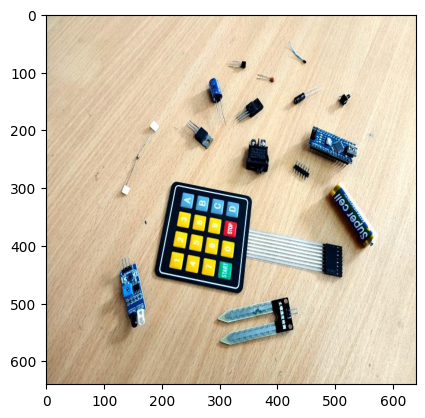

In [3]:
image = np.load(folder+'/test/images/IMG_20240228_122819_jpg.rf.549f931f79ce6af1acb40d1d98720cd7.npy')
plt.imshow(image)
image.shape

df = pd.read_csv(folder+'/test/labels/IMG_20240228_122819_jpg.rf.549f931f79ce6af1acb40d1d98720cd7.csv')
df

## 1.2 Checking Number of Images, Labels in Train, Test and Valid Folders

In [4]:
for i in ['train', 'valid', 'test']:
    path = os.path.join(folder, i)
    print(i)
    images_path = os.path.join(path, 'images')
    labels_path = os.path.join(path, 'labels')

    img_files = os.listdir(images_path)
    print(f"   images/: {len(img_files)} files")

    lab_files = os.listdir(labels_path)
    print(f"   labels/: {len(lab_files)} files")

train
   images/: 1422 files
   labels/: 1422 files
valid
   images/: 409 files
   labels/: 409 files
test
   images/: 200 files
   labels/: 200 files


## 2.1. Cropping
Each image contains a varying number of objects. The following code processes each split (train/valid/test) by loading every .npy image and its matching annotation CSV, computing pixel bounding boxes from x_center, y_center, width, and height, clamping them to image bounds, and cropping each object. Each crop is saved as a JPEG to dataset_cropped/'split'/'class'/ with the name 'image_basename'_obj'index'.jpg.

New 'dataset_cropped' folder has the following structure.


```
# dataset_cropped/
# | --/test
# | ----/0
# | ----/1
# | ...
# | ----/31
# | --/train
# | ----/0
# | ...
# | --/valid
# | ...
```




In [5]:
def crop(root_dir=folder+"/", output_dir = folder+'/dataset_cropped/'):
    splits = ['train', 'valid', 'test']

    for split in splits:
        images_dir = os.path.join(root_dir, split, 'images')
        labels_dir = os.path.join(root_dir, split, 'labels')

        image_files = sorted([i for i in os.listdir(images_dir) if i.endswith('.npy')])


        for img_file in image_files:
            img_path = os.path.join(images_dir, img_file)
            img_array = np.load(img_path)

            label_file = img_file.replace('.npy', '.csv')
            label_path = os.path.join(labels_dir, label_file)

            df = pd.read_csv(label_path)

            for obj_idx, row in df.iterrows():
                class_name = str(row['class']).strip()

                x_center = float(row['x_center'])
                y_center = float(row['y_center'])
                width = float(row['width'])
                height = float(row['height'])

                # Calculate bounding box
                x_min = int(x_center - width/2)
                y_min = int(y_center - height/2)
                x_max = int(x_center + width/2)
                y_max = int(y_center + height/2)

                # Ensure coordinates are within bounds
                img_h, img_w = img_array.shape[:2]
                x_min = max(0, x_min)
                y_min = max(0, y_min)
                x_max = min(img_w, x_max)
                y_max = min(img_h, y_max)

                # Skip invalid boxes
                if x_max <= x_min or y_max <= y_min:
                    continue

                # Crop object
                cropped = img_array[y_min:y_max, x_min:x_max]

                # Convert to PIL Image
                cropped = cropped.astype(np.uint8)
                img_pil = Image.fromarray(cropped)

                # Create class directory
                class_dir = os.path.join(output_dir, split, class_name)
                os.makedirs(class_dir, exist_ok = True)

                # Create output filename
                base_name = img_file.replace('.npy', '')
                output_name = f"{base_name}_obj{obj_idx}.jpg"
                output_path = os.path.join(class_dir, output_name)

                # Save image
                img_pil.save(output_path, quality = 95)

# run once only!
#stats = crop()

## 2.2. Summary of Images Present In Each Class After Cropping
check number of images for each label after crop
note that valid and test dont have the same number of classes with train
test: {3, 8, 12, 17, 24, 26} are missing
valid: {3, 8, 12, 24, 26} are missing
since both test and valid dataset have missing classes, need to check whether
images is labelled correctly later when loading

In [6]:
num_classes = 32

def count_per_class(folder, split, num_classes):
    base = os.path.join(folder, 'dataset_cropped', split)
    d = {}
    for j in range(num_classes):
        p = os.path.join(base, str(j))
        if os.path.isdir(p):
            d[j] = len([f for f in os.listdir(p) if not f.startswith('.')])
    return d

splits = ['train', 'valid', 'test']
counts = {s: count_per_class(folder, s, 32) for s in splits}

# Summary table of number of classes in train, valid and test folders
df = pd.DataFrame.from_dict(counts, orient='columns')
df = df.reindex(range(32)).fillna(0).astype(int) # Missing classes are filled with 0
df['Total'] = df.sum(axis=1)
totals_row = df.sum(axis=0)
df.loc['Total'] = totals_row
print(df)

present = {s: int((df.loc[range(32), s] > 0).sum()) for s in splits}
print("\nClasses present:", present)
missing = {s: [cid for cid in range(num_classes) if df.loc[cid, s] == 0] for s in splits}
print("\nMissing classes per split:")
for s in splits:
    print(f"  {s}: {missing[s]}")

       train  valid  test  Total
0         94    109     8    211
1         77     38    90    205
2        131     36    17    184
3        160      0     0    160
4        129     29    19    177
5         77    105    12    194
6        201      5     1    207
7        102    100    27    229
8        249      0     0    249
9        130     31    20    181
10       162     45    23    230
11       117     33    18    168
12       272      0     0    272
13        84    110    24    218
14        84    113    22    219
15        51     31    89    171
16       257      6     2    265
17       190      0     2    192
18        73     37    82    192
19        54     31    88    173
20       158     15     5    178
21       161      7     8    176
22       156     15     4    175
23       164     48    24    236
24       221      0     0    221
25       171      3     1    175
26       257      0     0    257
27       167     45    22    234
28       167     50    22    239
29       1

Found 4896 files belonging to 32 classes.


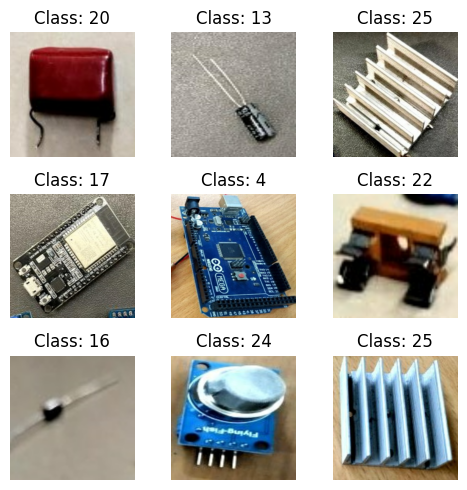

2025-10-31 10:42:29.727956: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# for visualisation only, import seperately so it wont affect our main training dataset
visualise = tf.keras.utils.image_dataset_from_directory(
    folder + '/dataset_cropped/train',
    image_size = (384, 384),
    batch_size = 32,
    label_mode = 'int',
    shuffle = True,
    seed = 1244
)

class_names = visualise.class_names

for images, labels in visualise.take(1):
    plt.figure(figsize = (5, 5))
    num_images = min(9, images.shape[0])

    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        img = images[i].numpy().astype("uint8")

        plt.imshow(img)
        plt.title(f"Class: {class_names[labels[i]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Statistical Thresholds Calculation:
Lower quartile (Q1): 91.5 samples
Upper quartile (Q3): 175.8 samples
Median: 159.0 samples
Mean: 153.0 samples
Range: 51 - 333 samples


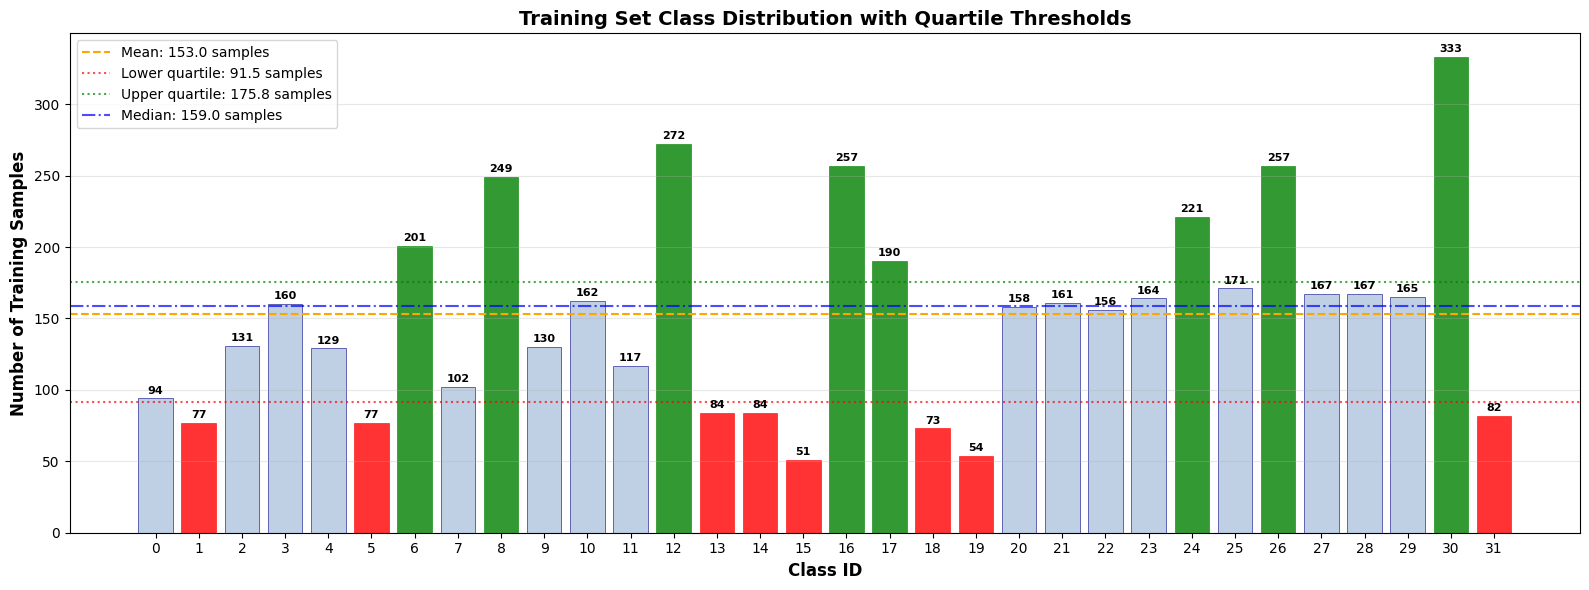


Training Set Imbalance Analysis
Total training samples: 4896
Average samples per class: 153.0
Most samples: Class 30 with 333 samples
Fewest samples: Class 15 with 51 samples
Imbalance ratio: 6.5x

Classes in Bottom 25% (LOW) (<91.5 samples): [1, 5, 13, 14, 15, 18, 19, 31]
Classes in Middle 50% (MEDIUM) (91.5-175.8 samples): 16 classes
Classes in Top 25% (HIGH) (>175.8 samples): [6, 8, 12, 16, 17, 24, 26, 30]

DETAILED CLASS COUNTS BY QUARTILE:
  Class  0:  94 samples - MEDIUM
  Class  1:  77 samples - LOW
  Class  2: 131 samples - MEDIUM
  Class  3: 160 samples - MEDIUM
  Class  4: 129 samples - MEDIUM
  Class  5:  77 samples - LOW
  Class  6: 201 samples - HIGH
  Class  7: 102 samples - MEDIUM
  Class  8: 249 samples - HIGH
  Class  9: 130 samples - MEDIUM
  Class 10: 162 samples - MEDIUM
  Class 11: 117 samples - MEDIUM
  Class 12: 272 samples - HIGH
  Class 13:  84 samples - LOW
  Class 14:  84 samples - LOW
  Class 15:  51 samples - LOW
  Class 16: 257 samples - HIGH
  Class 17: 

In [7]:
# Training set data only
class_ids = list(range(32))
train_samples = [94, 77, 131, 160, 129, 77, 201, 102, 249, 130, 162, 117, 272, 84, 84, 51, 257, 190, 73, 54, 158, 161, 156, 164, 221, 171, 257, 167, 167, 165, 333, 82]

# Create DataFrame for training data only
train_df = pd.DataFrame({
    'class_id': class_ids,
    'train_samples': train_samples
})

# Calculate statistical thresholds
Q1 = np.percentile(train_samples, 25)  # Lower quartile (25th percentile)
Q3 = np.percentile(train_samples, 75)  # Upper quartile (75th percentile)
median_samples = np.median(train_samples)
mean_samples = train_df['train_samples'].mean()
min_samples = train_df['train_samples'].min()
max_samples = train_df['train_samples'].max()

print("Statistical Thresholds Calculation:")
print("=" * 40)
print(f"Lower quartile (Q1): {Q1:.1f} samples")
print(f"Upper quartile (Q3): {Q3:.1f} samples")
print(f"Median: {median_samples:.1f} samples")
print(f"Mean: {mean_samples:.1f} samples")
print(f"Range: {min_samples} - {max_samples} samples")

# Training Set Distribution Plot
plt.figure(figsize=(16, 6))
bars = plt.bar(train_df['class_id'], train_df['train_samples'], 
               color='lightsteelblue', edgecolor='navy', alpha=0.8, linewidth=0.5)

# Color code based on quartile thresholds
for i, count in enumerate(train_samples):
    if count < Q1:  # Bottom 25% of classes
        bars[i].set_color('red')
    elif count > Q3:  # Top 25% of classes
        bars[i].set_color('green')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Add reference lines
plt.axhline(y=mean_samples, color='orange', linestyle='--', 
            label=f'Mean: {mean_samples:.1f} samples')
plt.axhline(y=Q1, color='red', linestyle=':', alpha=0.7, 
            label=f'Lower quartile: {Q1:.1f} samples')
plt.axhline(y=Q3, color='green', linestyle=':', alpha=0.7, 
            label=f'Upper quartile: {Q3:.1f} samples')
plt.axhline(y=median_samples, color='blue', linestyle='-.', alpha=0.7,
            label=f'Median: {median_samples:.1f} samples')

# Customize the plot
plt.xlabel('Class ID', fontsize=12, fontweight='bold')
plt.ylabel('Number of Training Samples', fontsize=12, fontweight='bold')
plt.title('Training Set Class Distribution with Quartile Thresholds', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(range(0, 32, 1))
plt.legend()
plt.tight_layout()
plt.show()

# Print training set statistics
print("\nTraining Set Imbalance Analysis")
print("=" * 50)
print(f"Total training samples: {sum(train_samples)}")
print(f"Average samples per class: {mean_samples:.1f}")
print(f"Most samples: Class {np.argmax(train_samples)} with {max_samples} samples")
print(f"Fewest samples: Class {np.argmin(train_samples)} with {min_samples} samples")
print(f"Imbalance ratio: {max_samples/min_samples:.1f}x")
print()

# Identify classes based on quartiles
low_sample_classes = [i for i, x in enumerate(train_samples) if x < Q1]
high_sample_classes = [i for i, x in enumerate(train_samples) if x > Q3]
medium_sample_classes = [i for i, x in enumerate(train_samples) if Q1 <= x <= Q3]

print(f"Classes in Bottom 25% (LOW) (<{Q1:.1f} samples): {low_sample_classes}")
print(f"Classes in Middle 50% (MEDIUM) ({Q1:.1f}-{Q3:.1f} samples): {len(medium_sample_classes)} classes")
print(f"Classes in Top 25% (HIGH) (>{Q3:.1f} samples): {high_sample_classes}")

# Additional detailed view
print("\nDETAILED CLASS COUNTS BY QUARTILE:")
for class_id, count in enumerate(train_samples):
    if count < Q1:
        status = "LOW"
    elif count > Q3:
        status = "HIGH"
    else:
        status = "MEDIUM"
    print(f"  Class {class_id:2d}: {count:3d} samples - {status}")

# Show distribution summary
print(f"\nDistribution Summary:")
print(f"Bottom 25%: {len(low_sample_classes)} classes (<{Q1:.1f} samples)")
print(f"Middle 50%: {len(medium_sample_classes)} classes ({Q1:.1f}-{Q3:.1f} samples)")
print(f"Top 25%: {len(high_sample_classes)} classes (>{Q3:.1f} samples)")

## 3.1. Handling Imbalanced Training Data using Class-Weight Computation

The following code computes per-class weights for the training set to mitigate class imbalance.

It uses each class's sample count to assign higher weights to rarer classes:

*weight_class_X = total_sample / (num_classes / samples_in_class_X)*

The resulting 'class_weights' dictionary maps each class ID to its weight.

In [8]:
# took it from above, handling class inbalance in the training dataset
class_counts = {0: 94, 1: 77, 2: 131, 3: 160, 4: 129, 5: 77, 6: 201,
                7: 102, 8: 249, 9: 130, 10: 162, 11: 117, 12: 272, 13: 84,
                14: 84, 15: 51, 16: 257, 17: 190, 18: 73, 19: 54, 20: 158,
                21: 161, 22: 156, 23: 164, 24: 221, 25: 171, 26: 257,
                27: 167, 28: 167, 29: 165, 30: 333, 31: 82}

classes = np.arange(32)
counts = np.array(list(class_counts.values()))

# Compute weights
class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes = classes,
    y = np.repeat(classes, counts)
)

class_weights = dict(zip(classes, class_weights_array))

## 3.2. Visualisation of Class-Weight Balancing

This analysis visualises the class imbalance in the training dataset and demonstrates how class weighting compensates for this imbalance. The four graphs show the original distribution, computed weights, their relationship, and the effective balanced dataset.

- Graph 1: Original Class Distribution
- Graph 2: Computed Class Weights
- Graph 3: Inverse Correlation between Sample Count and Class Weight
- Graph 4: Balanced Dataset with Effective Samples After Weighting

Result:
  -  Much more uniform distribution across classes

  - Reduced variance compared to original distribution

  - Each class now contributes more equally to the loss function

Training Impact: During gradient updates, minority classes have proportionally larger influence.




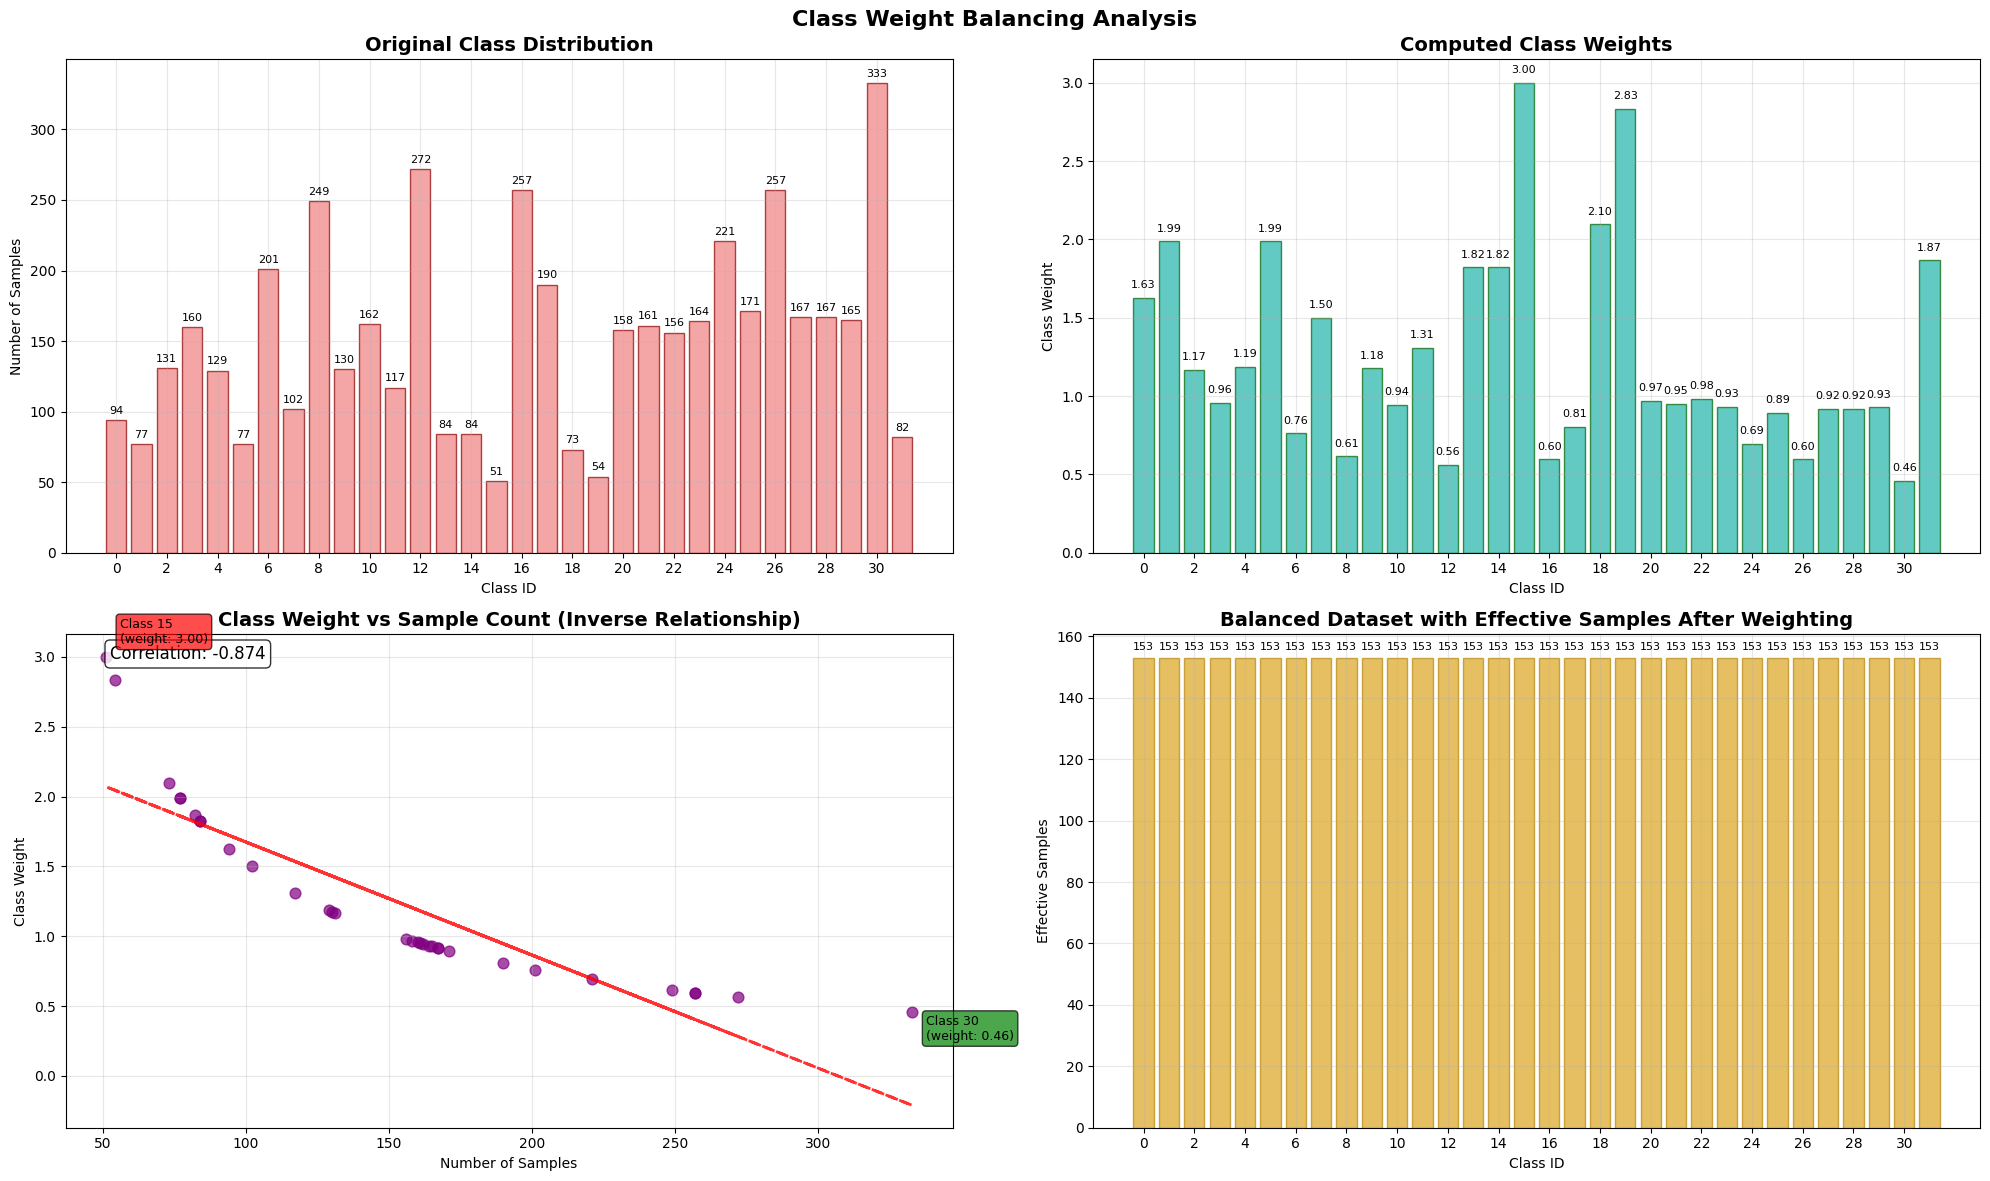

In [14]:
# Create comprehensive visualisation
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Class Weight Balancing Analysis', fontsize=16, fontweight='bold')

# Plot 1: Original class distribution
bars1 = ax1.bar(classes, counts, color='lightcoral', alpha=0.7, edgecolor='darkred')
ax1.set_title('Original Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class ID')
ax1.set_ylabel('Number of Samples')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 32, 2))

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{int(height)}', ha='center', va='bottom', fontsize=8)

# Plot 2: Computed class weights
bars2 = ax2.bar(classes, class_weights_array, color='lightseagreen', alpha=0.7, edgecolor='darkgreen')
ax2.set_title('Computed Class Weights', fontsize=14, fontweight='bold')
ax2.set_xlabel('Class ID')
ax2.set_ylabel('Class Weight')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 32, 2))

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# Plot 3: Weight vs Sample Count (inverse relationship)
ax3.scatter(counts, class_weights_array, s=60, alpha=0.7, color='purple')
ax3.set_title('Class Weight vs Sample Count (Inverse Relationship)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Samples')
ax3.set_ylabel('Class Weight')
ax3.grid(True, alpha=0.3)

# Add correlation line and annotation
z = np.polyfit(counts, class_weights_array, 1)
p = np.poly1d(z)
ax3.plot(counts, p(counts), "r--", alpha=0.8, linewidth=2)

correlation = np.corrcoef(counts, class_weights_array)[0,1]
ax3.text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=ax3.transAxes, 
         fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Annotate extreme points
max_weight_idx = np.argmax(class_weights_array)
min_weight_idx = np.argmin(class_weights_array)
ax3.annotate(f'Class {max_weight_idx}\n(weight: {class_weights_array[max_weight_idx]:.2f})', 
             xy=(counts[max_weight_idx], class_weights_array[max_weight_idx]),
             xytext=(10, 10), textcoords='offset points', fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.7))
ax3.annotate(f'Class {min_weight_idx}\n(weight: {class_weights_array[min_weight_idx]:.2f})', 
             xy=(counts[min_weight_idx], class_weights_array[min_weight_idx]),
             xytext=(10, -20), textcoords='offset points', fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="green", alpha=0.7))

# Plot 4: Effective samples after weighting
effective_samples = counts * class_weights_array
bars4 = ax4.bar(classes, effective_samples, color='goldenrod', alpha=0.7, edgecolor='darkgoldenrod')
ax4.set_title('Balanced Dataset with Effective Samples After Weighting', fontsize=14, fontweight='bold')
ax4.set_xlabel('Class ID')
ax4.set_ylabel('Effective Samples')
ax4.grid(True, alpha=0.3)
ax4.set_xticks(range(0, 32, 2))

# Add value labels on bars
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Building TensorFlow Datasets

This code builds TensorFlow datasets from the cropped images and captures each split's label mapping.

Datasets: Loads images from dataset_cropped/{train,valid,test}/'class_id'/... via tf.keras.utils.image_dataset_from_directory, resizing to 384x384, with integer labels and no batching. Only the train split is shuffled (seeded for reproducibility).

Label maps: Reads class_names (folder names) for each split and creates {dataset_label_index → actual_class_id} by converting folder names to integers.

In [4]:
# importing train/val/test data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    folder + '/dataset_cropped/train',
    image_size = (384, 384),
    batch_size = None,
    label_mode = 'int',
    shuffle = True,
    seed = 1244
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    folder + '/dataset_cropped/valid',
    image_size = (384, 384),
    batch_size = None,
    label_mode = 'int',
    shuffle = False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    folder + '/dataset_cropped/test',
    image_size = (384, 384),
    batch_size = None,
    label_mode = 'int',
    shuffle = False
)

train_class_names = train_dataset.class_names
train_label_map = {i: int(folder_name) for i, folder_name in enumerate(train_class_names)}
print(f"Train label mapping: {train_label_map}")

val_class_names = val_dataset.class_names
val_label_map = {i: int(folder_name) for i, folder_name in enumerate(val_class_names)}
print(f"Val label mapping: {val_label_map}")

test_class_names = test_dataset.class_names
test_label_map = {i: int(folder_name) for i, folder_name in enumerate(test_class_names)}
print(f"Test label mapping: {test_label_map}")

Found 4896 files belonging to 32 classes.
Found 1209 files belonging to 26 classes.
Found 669 files belonging to 27 classes.
Train label mapping: {0: 0, 1: 1, 2: 10, 3: 11, 4: 12, 5: 13, 6: 14, 7: 15, 8: 16, 9: 17, 10: 18, 11: 19, 12: 2, 13: 20, 14: 21, 15: 22, 16: 23, 17: 24, 18: 25, 19: 26, 20: 27, 21: 28, 22: 29, 23: 3, 24: 30, 25: 31, 26: 4, 27: 5, 28: 6, 29: 7, 30: 8, 31: 9}
Val label mapping: {0: 0, 1: 1, 2: 10, 3: 11, 4: 13, 5: 14, 6: 15, 7: 16, 8: 18, 9: 19, 10: 2, 11: 20, 12: 21, 13: 22, 14: 23, 15: 25, 16: 27, 17: 28, 18: 29, 19: 30, 20: 31, 21: 4, 22: 5, 23: 6, 24: 7, 25: 9}
Test label mapping: {0: 0, 1: 1, 2: 10, 3: 11, 4: 13, 5: 14, 6: 15, 7: 16, 8: 17, 9: 18, 10: 19, 11: 2, 12: 20, 13: 21, 14: 22, 15: 23, 16: 25, 17: 27, 18: 28, 19: 29, 20: 30, 21: 31, 22: 4, 23: 5, 24: 6, 25: 7, 26: 9}


## 5. Data Augmentation
This code defines a simple data-augmentation pipeline for the training data.


*   img_augmentation_layers: a list of Keras preprocessing layers applied in order:
    - RandomRotation(factor=0.15): rotates each image by a random angle in ±0.15*2π radians (≈ ±54°).

    - RandomTranslation(0.1, 0.1): shifts up to ±10% of image height/width.

    - RandomFlip(): default is horizontal and vertical flips.

    - RandomContrast(0.1): adjusts contrast by ±10%.

*   img_augmentation(images): loops through the list, passing the batch tensor through each layer sequentially, returning the augmented batch

Purpose: This is a technique utilised by Özkan & Dündar (2023) to detect electrical components where data augmentation can strategically enlarge the training dataset, which mitigates overfitting and enhances the model's resilience to unseen geometric and photometric variations.

https://www.ijcesen.com/index.php/ijcesen/article/view/855

https://medium.com/accredian/increase-the-performance-of-image-classification-models-b466e1ae31



In [5]:
# data augmentation for training data only
img_augmentation_layers = [
    layers.RandomRotation(factor = 0.15),
    layers.RandomTranslation(height_factor = 0.1, width_factor = 0.1),
    layers.RandomFlip(),
    layers.RandomContrast(factor = 0.1),
]

def img_augmentation(images):
    for layer in img_augmentation_layers:
        images = layer(images)
    return images

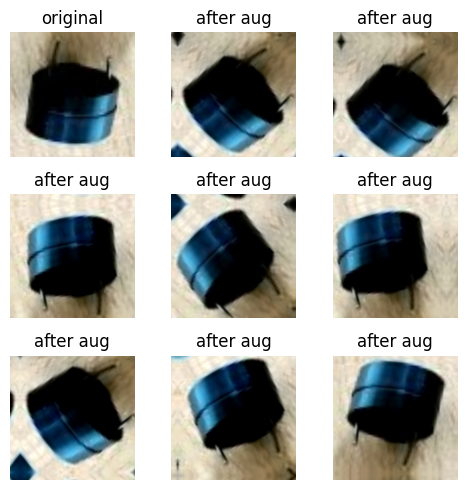

In [6]:
# visualisation of image after augmentation
class_names = np.arange(32)

for image, label in train_dataset.take(1):
    first_image = image
    first_label = label.numpy()

    plt.figure(figsize = (5, 5))
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        if i == 0:
            img = first_image.numpy().astype("uint8")
            plt.title('original')
        else:
            aug_img = img_augmentation(tf.expand_dims(first_image, 0))
            img = aug_img[0].numpy().astype("uint8")
            plt.title('after aug')
        plt.imshow(img)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    break

## 6. Labelling
- Maps each (image, label) to (augmented_image, one_hot_label) using remap dicts.
- Same for val/test (minus augmentation).
- Transforms labels into one-hot encoded format for 32-class classification, ensuring consistent label formatting across datasets.
- Resizes all images to 384x384x3 resolution.
- Sets fixed output shapes for both images (32,) and labels (32,).
- Groups data into batches of 64.


Note: Run only once as it overwrites train/val/test dataset with batched datasets, running the code cell again will raise an error as it expects unbatched datasets.

In [7]:
def input_preprocess_train(image, label):
    image = img_augmentation(image)
    def remap_fn(lbl):
        return train_label_map[int(lbl)]

    actual_label = tf.numpy_function(remap_fn, [label], tf.int64)
    actual_label = tf.cast(actual_label, tf.int32)
    actual_label = tf.one_hot(actual_label, 32)

    image.set_shape([384, 384, 3])
    actual_label.set_shape([32])

    return image, actual_label

def input_preprocess_val(image, label):
    def remap_fn(lbl):
        return val_label_map[int(lbl)]

    actual_label = tf.numpy_function(remap_fn, [label], tf.int64)
    actual_label = tf.cast(actual_label, tf.int32)
    actual_label = tf.one_hot(actual_label, 32)

    image.set_shape([384, 384, 3])
    actual_label.set_shape([32])

    return image, actual_label

def input_preprocess_test(image, label):
    def remap_fn(lbl):
        return test_label_map[int(lbl)]

    actual_label = tf.numpy_function(remap_fn, [label], tf.int64)
    actual_label = tf.cast(actual_label, tf.int32)
    actual_label = tf.one_hot(actual_label, 32)

    image.set_shape([384, 384, 3])
    actual_label.set_shape([32])

    return image, actual_label


train_dataset = train_dataset.map(input_preprocess_train, num_parallel_calls = tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(batch_size = 64, drop_remainder = True)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.map(input_preprocess_val, num_parallel_calls = tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size = 64, drop_remainder = False)

test_dataset = test_dataset.map(input_preprocess_test, num_parallel_calls = tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size = 64, drop_remainder = False)


In [ ]:
def cv_preprocess_train(image, label):
    image = img_augmentation(image)
    label = tf.one_hot(label, 32)
    return image, label


def cv_preprocess_test(image, label):
    label = tf.one_hot(label, 32)
    return image, label

## 7. Model: EfficientNetV2S

EfficientNetV2-S is a compact and efficient pre-trained convolutional neural network (CNN) architecture with Fused-MBConv blocks that reduce computational power, introduced in 2021 and designed for fast training and high performance on image classification tasks.

https://www.emergentmind.com/topics/efficientnetv2-s-with-transfer-learning 

Pre-trained models reduce data and computational requirements by leveraging learned features such as color and shape, enabling faster and more efficient training on our custom dataset. 

https://www.researchgate.net/publication/333080572_Transfer_Learning_for_Small_Dataset

### 7.1. Finding Optimal Epoch Number using Stratified 3-Fold Training Pipeline

1. Load Data: Reads all training images and their labels from disk

2. Split Data: Uses stratified splitting to maintain class distribution in each fold

3. Create 3 Training Cycles:

    - For each fold, 2/3 of data trains the model, 1/3 validates it

    - This repeats 3 times with different splits

4. Build Model Each Time: Each fold creates a new:

    - Base: EfficientNetV2-S (pre-trained on ImageNet)

    - Head: Custom classification layer for 32 classes

    - Training: 10 epochs with class weights to handle imbalanced data

Track Results: Stores training history for each fold to compare performance

In [ ]:
from sklearn.model_selection import StratifiedKFold

# load train data for 3 fold cross validation
train_df = tf.keras.utils.image_dataset_from_directory(
    folder + '/dataset_cropped/train',
    image_size = (384, 384),
    batch_size = None,
    label_mode = 'int',
    shuffle = False,
    seed = 1244
)

file_paths = np.array(train_df.file_paths)
labels = np.array([label.numpy() for _, label in train_df])

skfold = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 1244)

def create_fold_dataset(paths, labels, batch_size = 64, shuffle = True):
    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels = 3, expand_animations = False)
        img = tf.image.resize(img, [384, 384])
        img = tf.cast(img, tf.float32)

        return img, label

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size = len(paths), seed = 1244)

    dataset = dataset.map(load_image, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)

    return dataset

Found 4896 files belonging to 32 classes.


2025-10-31 10:42:31.110112: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
histories = {}

for fold_no, (train_idx, val_idx) in enumerate(skfold.split(file_paths, labels), 1):
    print(f'Training Fold {fold_no}')

    train_paths = file_paths[train_idx]
    val_paths = file_paths[val_idx]
    train_labels = labels[train_idx]
    val_labels = labels[val_idx]

    train_fold_dataset = create_fold_dataset(train_paths, train_labels, batch_size = 64, shuffle = True)
    val_fold_dataset = create_fold_dataset(val_paths, val_labels, batch_size = 64, shuffle = False)

    train_fold_dataset = train_fold_dataset.map(
        cv_preprocess_train,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    train_fold_dataset = train_fold_dataset.prefetch(tf.data.AUTOTUNE)

    val_fold_dataset = val_fold_dataset.map(
        cv_preprocess_test,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    val_fold_dataset = val_fold_dataset.prefetch(tf.data.AUTOTUNE)

    classes = np.unique(train_labels)
    class_weights = compute_class_weight(
        class_weight = 'balanced',
        classes = classes,
        y = train_labels
    )

    class_weight_dict = dict(zip(classes, class_weights))

    temp_model = keras.applications.EfficientNetV2S(
        weights = 'imagenet',
        input_shape = (384, 384, 3),
        include_top = False)

    temp_model.trainable = False

    inputs = keras.Input(shape = (384, 384, 3))

    x = temp_model(inputs, training = False)

    x = keras.layers.GlobalAveragePooling2D()(x)

    outputs = keras.layers.Dense(32, activation='softmax')(x) # 32 output classes

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    fold_history = model.fit(
        train_fold_dataset,
        validation_data = val_fold_dataset,
        class_weight = class_weight_dict,
        epochs = 10,
        verbose = 1
    )

    histories[fold_no] = fold_history

Training Fold 1
Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 315s 6s/step - accuracy: 0.5227 - loss: 2.4217 - val_accuracy: 0.8174 - val_loss: 1.4083
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 337s 7s/step - accuracy: 0.8434 - loss: 1.1918 - val_accuracy: 0.8664 - val_loss: 0.8412
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 360s 7s/step - accuracy: 0.8735 - loss: 0.8024 - val_accuracy: 0.8989 - val_loss: 0.6173
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 368s 7s/step - accuracy: 0.9032 - loss: 0.6170 - val_accuracy: 0.9142 - val_loss: 0.5064
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 377s 7s/step - accuracy: 0.9185 - loss: 0.5003 - val_accuracy: 0.9203 - val_loss: 0.4346
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 376s 7s/step - accuracy: 0.9268 - loss: 0.4341 - val_accuracy: 0.9301 - val_loss: 0.3799
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 743s 15s/step - accuracy: 0.9308 - loss: 0.3828 - val_accuracy: 0.9350 - val_loss: 0.3444
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 718s 14s/step - accuracy: 0.9427 - loss: 0.3386 - val_ac

### 7.2. Graphs of Training vs. Validation Loss/Accuracy over 10 Epochs for Each Fold

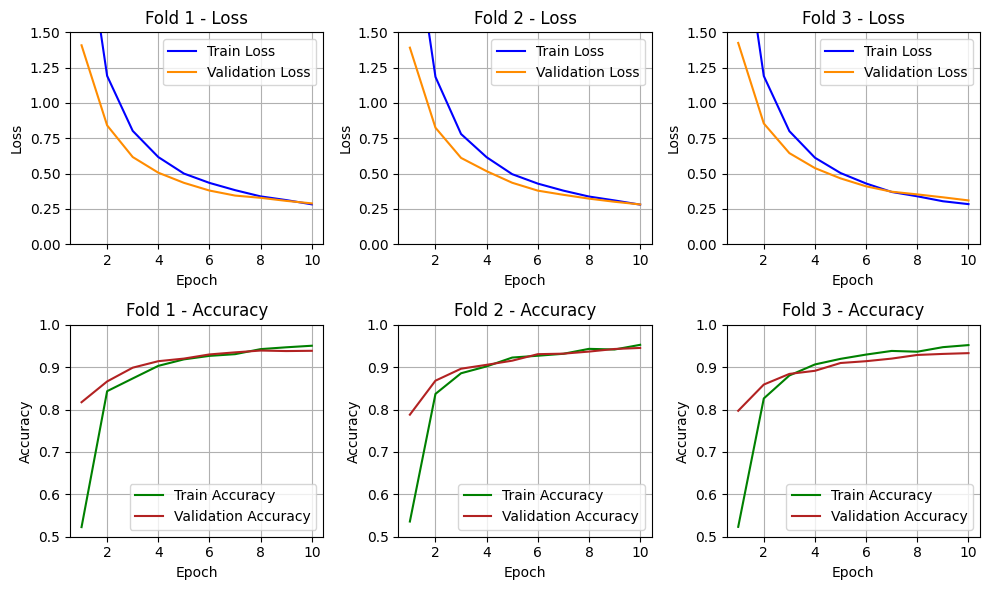

In [ ]:
fig, axes = plt.subplots(2, 3, figsize = (10, 6))
epochs = range(1, 11)

for i in range(1, 4):
    history = histories[i]
    train_loss = history.history['loss']
    train_acc = history.history['accuracy']
    val_loss = history.history['val_loss']
    val_acc = history.history['val_accuracy']

    # Top row: Loss plots
    axes[0, i - 1].plot(epochs, train_loss, color = 'blue', label = 'Train Loss')
    axes[0, i - 1].plot(epochs, val_loss, color = 'darkorange', label = 'Validation Loss')
    axes[0, i - 1].set_ylim(0, 1.5)
    axes[0, i - 1].set_title(f"Fold {i} - Loss")
    axes[0, i - 1].set_xlabel('Epoch')
    axes[0, i - 1].set_ylabel('Loss')
    axes[0, i - 1].legend()
    axes[0, i - 1].grid(True)

    # Bottom row: Accuracy plots
    axes[1, i - 1].plot(epochs, train_acc, color = 'green', label = 'Train Accuracy')
    axes[1, i - 1].plot(epochs, val_acc, color = 'firebrick', label = 'Validation Accuracy')
    axes[1, i - 1].set_ylim(0.5, 1.0)
    axes[1, i - 1].set_title(f"Fold {i} - Accuracy")
    axes[1, i - 1].set_xlabel('Epoch')
    axes[1, i - 1].set_ylabel('Accuracy')
    axes[1, i - 1].legend()
    axes[1, i - 1].grid(True)

plt.tight_layout()
plt.show()

**Loss**
- After epoch 8, validation loss reaches plateau and slightly increasing to be larger than training loss.
- Model is potentially overfitting after epoch 8.

**Accuracy**
- Validation accuracy reaches above 80% accuracy by epoch 2 across all 3 folds and increase in a much slower rate afterwards.
- For the first fold, train accuracy and validation accuracy curve intersects around epoch 7, while fold 2 and 3 intersects at epoch 3 - 4. Train accuracy starts to diverge above validation accuracy around epoch 8.
- After epoch 8, improvements become marginal and a slight divergence appears, suggesting potential overfitting if training continues.

**Conclusion:**
Therefore, training for around 8 epochs provides a good balance between accuracy (~94%) and overfitting.

### 7.3. Training

Similar to 7.1, this model training process
  - uses the complete training dataset (not split into folds)
  - validates on val set
  - trains for 8 epochs with class-weight balancing



In [ ]:
model = keras.applications.EfficientNetV2S(
    weights = 'imagenet',
    input_shape = (384, 384, 3),
    include_top = False)

model.trainable = False

inputs = keras.Input(shape = (384, 384, 3))

x = model(inputs, training = False)

x = keras.layers.GlobalAveragePooling2D()(x)

outputs = keras.layers.Dense(32, activation='softmax')(x) # 32 output classes

model = keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# run it again since class_weights object is override by the 3-fold cv above which uses the same name
class_counts = {0: 94, 1: 77, 2: 131, 3: 160, 4: 129, 5: 77, 6: 201,
                7: 102, 8: 249, 9: 130, 10: 162, 11: 117, 12: 272, 13: 84,
                14: 84, 15: 51, 16: 257, 17: 190, 18: 73, 19: 54, 20: 158,
                21: 161, 22: 156, 23: 164, 24: 221, 25: 171, 26: 257,
                27: 167, 28: 167, 29: 165, 30: 333, 31: 82}

classes = np.arange(32)
counts = np.array(list(class_counts.values()))

# Compute weights
class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes = classes,
    y = np.repeat(classes, counts)
)

class_weights = dict(zip(classes, class_weights_array))

In [ ]:
history = model.fit(train_dataset, epochs = 8,
                    validation_data = val_dataset,
                    class_weight = class_weights)

Epoch 1/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 6467s 86s/step - accuracy: 0.6460 - loss: 2.0178 - val_accuracy: 0.7899 - val_loss: 1.2197
Epoch 2/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 738s 10s/step - accuracy: 0.8647 - loss: 0.8838 - val_accuracy: 0.8577 - val_loss: 0.7876
Epoch 3/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 661s 9s/step - accuracy: 0.9030 - loss: 0.5946 - val_accuracy: 0.8867 - val_loss: 0.6005
Epoch 4/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 525s 7s/step - accuracy: 0.9208 - loss: 0.4680 - val_accuracy: 0.8925 - val_loss: 0.5390
Epoch 5/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 520s 7s/step - accuracy: 0.9336 - loss: 0.3832 - val_accuracy: 0.9032 - val_loss: 0.4718
Epoch 6/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 520s 7s/step - accuracy: 0.9414 - loss: 0.3335 - val_accuracy: 0.9090 - val_loss: 0.4291
Epoch 7/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 512s 7s/step - accuracy: 0.9416 - loss: 0.3056 - val_accuracy: 0.9115 - val_loss: 0.4093
Epoch 8/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 501s 7s/step - accuracy: 0.9515 - loss: 0.2656 - val_accuracy: 0.9156 - val_lo

### 7.4. Graphs of Training vs. Validation Loss/Accuracy across 8 Epochs

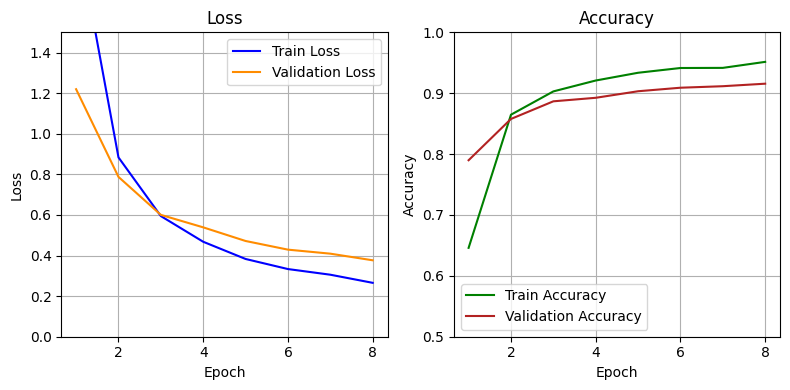

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (8, 4))
epochs = range(1, len(history.history['loss']) + 1)

train_loss = history.history['loss']
train_acc = history.history['accuracy']
val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']

axes[0].plot(epochs, train_loss, color = 'blue', label = 'Train Loss')
axes[0].plot(epochs, val_loss, color = 'darkorange', label = 'Validation Loss')
axes[0].set_ylim(0, 1.5)
axes[0].set_title(f"Loss")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_acc, color = 'green', label = 'Train Accuracy')
axes[1].plot(epochs, val_acc, color = 'firebrick', label = 'Validation Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title(f"Accuracy")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 7.5. Confusion Matrix of True Classes against Predicted Classes

In [ ]:
y, y_hat = [], []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose = 0)
    y_hat.append(np.argmax(predictions, axis = 1))
    y.append(np.argmax(labels.numpy(), axis = 1))

y, y_hat = np.concatenate(y), np.concatenate(y_hat)

val_class_distribution = {0: 109, 1: 38, 2: 36, 4: 29, 5: 105, 6: 5, 7: 100, 9: 31, 10: 45, 11: 33, 13: 110,
                          14: 113, 15: 31, 16: 6, 18: 37, 19: 31, 20: 15, 21: 7, 22: 15, 23: 48, 25: 3, 27: 45,
                          28: 50, 29: 44, 30: 4, 31: 119}
valid_classes = list(val_class_distribution.keys())
missing_classes = [i for i in range(32) if i not in valid_classes]

overall_acc = np.mean(y_hat == y)
missing_mask = np.isin(y_hat, missing_classes)
valid_mask = np.isin(y_hat, valid_classes)
filtered_acc = np.mean(y_hat[valid_mask] == y[valid_mask])

print(f"EfficientNetV2S Model Performance:")
print(f"Overall Accuracy: {overall_acc*100:.2f}%")
print(f"Filtered Accuracy (valid classes only): {filtered_acc*100:.2f}%")
print(f"Number of predictions in missing classes: {np.sum(missing_mask)}")

EfficientNetV2S Model Performance:
Overall Accuracy: 91.56%
Filtered Accuracy (valid classes only): 92.95%
Number of predictions in missing classes: 18


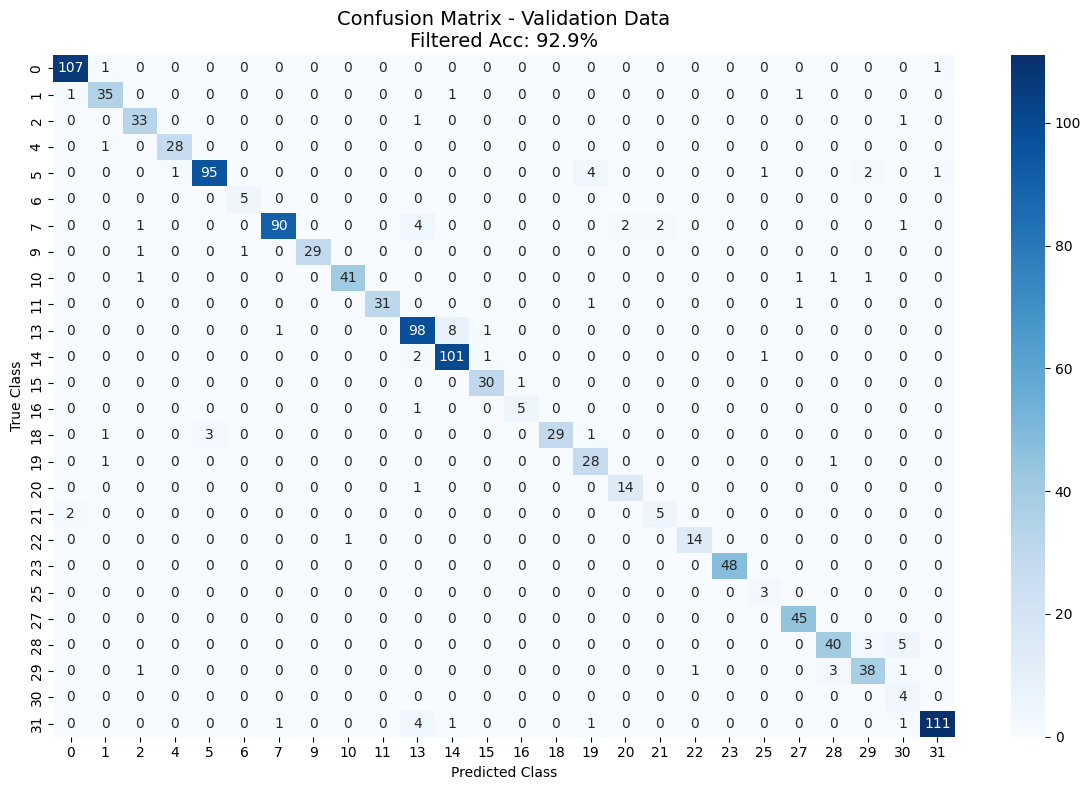


EfficientNetV2S Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       109
           1       0.90      0.92      0.91        38
           2       0.89      0.92      0.90        36
           4       0.97      0.97      0.97        29
           5       0.97      0.90      0.94       105
           6       0.83      1.00      0.91         5
           7       0.98      0.90      0.94       100
           9       1.00      0.94      0.97        31
          10       0.98      0.91      0.94        45
          11       1.00      0.94      0.97        33
          13       0.88      0.89      0.89       110
          14       0.91      0.89      0.90       113
          15       0.94      0.97      0.95        31
          16       0.83      0.83      0.83         6
          18       1.00      0.78      0.88        37
          19       0.80      0.90      0.85        31
          20       0.88      0.93      0.

In [ ]:
cm = confusion_matrix(y, y_hat, labels=valid_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=valid_classes,
            yticklabels=valid_classes)
plt.title(f'Confusion Matrix - Validation Data\nFiltered Acc: {filtered_acc*100:.1f}%',
          fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

print("\nEfficientNetV2S Classification Report:")
print(classification_report(y, y_hat,
                           labels=valid_classes,
                           target_names=[str(cls) for cls in valid_classes],
                           zero_division=0))

### 7.6. Export Model
The model will be saved in the 'models' folder located in the same directory as this .ipynb file.

In [ ]:
# Define your desired directory
save_dir = './models'
model_name = 'EfficientNetV2S_model.keras'

# Create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save to that directory
model_path = os.path.join(save_dir, model_name)
model.save(model_path)
print(f"Model saved to: {model_path}")

Model saved to: ./models/EfficientNetV2S_model.keras


## 8. Model: ResNet50

ResNet50 is a deep CNN model introduced in 2015 known for its residual connections, which are simple paths that allow information skip ahead instead of going through every layer in the model, making the learning more stable and efficient.

https://www.ultralytics.com/blog/what-is-resnet-50-and-what-is-its-relevance-in-computer-vision

### 8.1. Finding Optimal Epoch Number using Stratified 3-Fold Training Pipeline

1. Load & Prepare Data:

    - Loads training images resized to 224×224 (ResNet50's preferred size)

    - Uses stratified splitting to maintain class balance across folds

2. Create 3 Training Cycles:

    - Each fold: 2/3 data for training, 1/3 for validation

    - Repeats 3 times with different splits

3. Build ResNet50 Model Each Time:

    - Base: ResNet50 (pre-trained on ImageNet)

    - Custom Head: Global pooling + 32-class classification layer

    - Training: 10 epochs with class weights for imbalance

In [ ]:
ssl._create_default_https_context = ssl._create_unverified_context

train_df = tf.keras.utils.image_dataset_from_directory(
    folder + '/dataset_cropped/train',
    image_size=(224,224),
    batch_size=None,
    label_mode='int',
    shuffle=False,
    seed=1244
)

file_paths = np.array(train_df.file_paths)
labels = np.array([label.numpy() for _, label in train_df])

skfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=1244)

resnet_histories = {}

def create_fold_dataset(paths, labels, batch_size=64, shuffle=False):
    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [224, 224])  # ResNet input size
        img = tf.cast(img, tf.float32)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=1244)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size)

Found 4896 files belonging to 32 classes.


2025-10-31 20:37:49.313061: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
for fold_no, (train_idx, val_idx) in enumerate(skfold.split(file_paths, labels), 1):
    print(f"\n===== Training ResNet50 Fold {fold_no} =====\n")


    train_paths, val_paths = file_paths[train_idx], file_paths[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]

    train_fold_dataset = create_fold_dataset(train_paths, train_labels, shuffle=True)
    val_fold_dataset   = create_fold_dataset(val_paths, val_labels, shuffle=False)


    train_fold_dataset = train_fold_dataset.map(cv_preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    val_fold_dataset   = val_fold_dataset.map(cv_preprocess_test,  num_parallel_calls=tf.data.AUTOTUNE)


    unique_classes, counts = np.unique(train_labels, return_counts=True)
    class_weight_values = compute_class_weight("balanced", classes=unique_classes, y=train_labels)
    class_weight_dict = {cls: w for cls, w in zip(unique_classes, class_weight_values)}


    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    base.trainable = False

    inputs = keras.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(32, activation='softmax')(x)
    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_fold_dataset,
        validation_data=val_fold_dataset,
        class_weight=class_weight_dict,
        epochs=10,
        verbose=1
    )

    resnet_histories[fold_no] = history


===== Training ResNet50 Fold 1 =====

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.5279 - loss: 1.9064 - val_accuracy: 0.8082 - val_loss: 0.7495
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8606 - loss: 0.6183 - val_accuracy: 0.8799 - val_loss: 0.4802
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9105 - loss: 0.4180 - val_accuracy: 0.9136 - val_loss: 0.3640
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.9308 - loss: 0.3137 - val_accuracy: 0.9173 - val_loss: 0.3248
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.9381 - loss: 0.2568 - val_accuracy: 0.9240 - val_loss: 0.2869
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9485 - loss: 0.2236 - val_accuracy: 0.9375 - val_loss: 0.2562
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9593 - loss: 0.1812 - val_accuracy: 0.9259 - val_loss: 0.2659
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9617 - 

### 8.2. Graphs of Training vs. Validation Loss/Accuracy over 10 Epochs for Each Fold

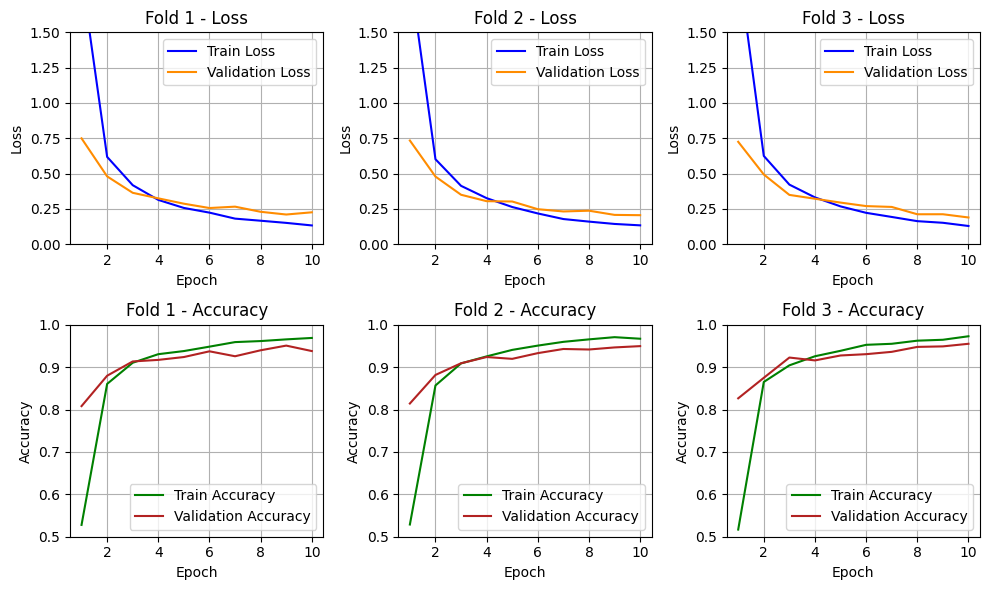

In [ ]:
fig, axes = plt.subplots(2, 3, figsize = (10, 6))
epochs = range(1, 11)

for i in range(1, 4):
    history = resnet_histories[i]
    train_loss = history.history['loss']
    train_acc = history.history['accuracy']
    val_loss = history.history['val_loss']
    val_acc = history.history['val_accuracy']

    axes[0, i - 1].plot(epochs, train_loss, color = 'blue', label = 'Train Loss')
    axes[0, i - 1].plot(epochs, val_loss, color = 'darkorange', label = 'Validation Loss')
    axes[0, i - 1].set_ylim(0, 1.5)
    axes[0, i - 1].set_title(f"Fold {i} - Loss")
    axes[0, i - 1].set_xlabel('Epoch')
    axes[0, i - 1].set_ylabel('Loss')
    axes[0, i - 1].legend()
    axes[0, i - 1].grid(True)

    axes[1, i - 1].plot(epochs, train_acc, color = 'green', label = 'Train Accuracy')
    axes[1, i - 1].plot(epochs, val_acc, color = 'firebrick', label = 'Validation Accuracy')
    axes[1, i - 1].set_ylim(0.5, 1.0)
    axes[1, i - 1].set_title(f"Fold {i} - Accuracy")
    axes[1, i - 1].set_xlabel('Epoch')
    axes[1, i - 1].set_ylabel('Accuracy')
    axes[1, i - 1].legend()
    axes[1, i - 1].grid(True)

plt.tight_layout()
plt.show()

**Loss**
- After epoch 6, validation loss plateaus while training loss continues to decrease.

- Validation loss stabilises at a higher level than training loss, indicating reduced learning progress.

**Accuracy**
- Training accuracy consistently exceeds validation accuracy across all three folds after epoch 6.

- The gap between training and validation accuracy widens progressively after epoch 6.

- Validation accuracy stabilises around 94% while training accuracy continues to improve.

**Conclusion**: Training for approximately 6 epochs provides optimal balance between accuracy (~94%) and generalisation, preventing significant overfitting.



### 8.3. Training


Similar to 8.1, this model training process
  - uses the complete training dataset (not split into folds)
  - validates on val set
  - trains for 6 epochs with class-weight balancing

In [10]:
def create_proper_dataset(dataset):
    dataset = dataset.unbatch()

    def resize_for_resnet(image, label):
        image = tf.image.resize(image, (224, 224))
        return image, label

    dataset = dataset.map(resize_for_resnet, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(64)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

resnet_train = create_proper_dataset(train_dataset)
resnet_val = create_proper_dataset(val_dataset)

In [ ]:
model2 = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model2.trainable = False
inputs = keras.Input(shape = (224, 224, 3))

x = model2(inputs, training = False)

x = keras.layers.GlobalAveragePooling2D()(x)

outputs = keras.layers.Dense(32, activation='softmax')(x)

model2 = keras.Model(inputs, outputs)

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
for images, labels in resnet_train.take(1):
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    break

Images shape: (64, 224, 224, 3)
Labels shape: (64, 32)


In [ ]:
history2 = model2.fit(resnet_train, validation_data=resnet_val,
                      epochs = 6,
                      class_weight=class_weights
)

Epoch 1/6
76/76 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.6160 - loss: 1.5793 - val_accuracy: 0.8048 - val_loss: 0.7640
Epoch 2/6


/Users/BonnieToo/Personal/university/IT1244/ECI/venv-eci/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


76/76 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.8960 - loss: 0.4702 - val_accuracy: 0.8685 - val_loss: 0.5372
Epoch 3/6
76/76 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9252 - loss: 0.3261 - val_accuracy: 0.8892 - val_loss: 0.4272
Epoch 4/6
76/76 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9385 - loss: 0.2625 - val_accuracy: 0.8925 - val_loss: 0.4030
Epoch 5/6


2025-10-31 21:50:49.101489: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


76/76 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9457 - loss: 0.2168 - val_accuracy: 0.8966 - val_loss: 0.3708
Epoch 6/6
76/76 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9581 - loss: 0.1837 - val_accuracy: 0.8950 - val_loss: 0.3778


### 8.4. Graphs of Training vs. Validation Loss/Accuracy across 6 Epochs

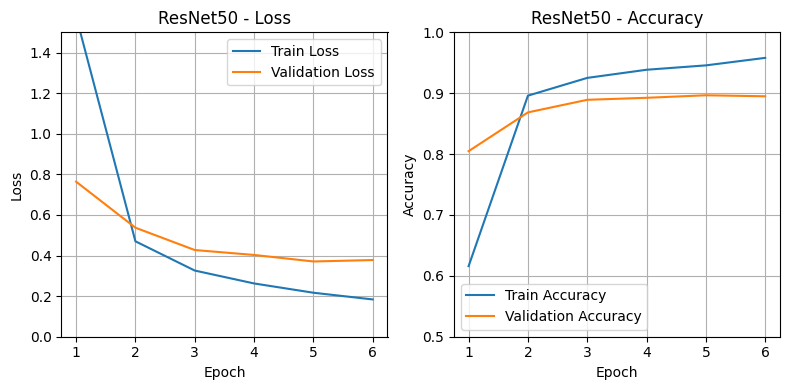

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

epochs = range(1, len(history2.history['loss']) + 1)

train_loss = history2.history['loss']
val_loss   = history2.history['val_loss']
train_acc  = history2.history['accuracy']
val_acc    = history2.history['val_accuracy']

# Loss
axes[0].plot(epochs, train_loss, label='Train Loss')
axes[0].plot(epochs, val_loss, label='Validation Loss')
axes[0].set_ylim(0, 1.5)
axes[0].set_title('ResNet50 - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, train_acc, label='Train Accuracy')
axes[1].plot(epochs, val_acc, label='Validation Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('ResNet50 - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### 8.5. Confusion Matrix of True Classes against Predicted Classes

In [ ]:
# Generate predictions for ResNet50 model
y_resnet, y_hat_resnet = [], []

for images, labels in resnet_val:
    predictions = model2.predict(images, verbose=0)
    y_hat_resnet.append(np.argmax(predictions, axis=1))
    y_resnet.append(np.argmax(labels.numpy(), axis=1))

y_resnet, y_hat_resnet = np.concatenate(y_resnet), np.concatenate(y_hat_resnet)

val_class_distribution = {0: 109, 1: 38, 2: 36, 4: 29, 5: 105, 6: 5, 7: 100, 9: 31, 10: 45, 11: 33, 13: 110,
                          14: 113, 15: 31, 16: 6, 18: 37, 19: 31, 20: 15, 21: 7, 22: 15, 23: 48, 25: 3, 27: 45,
                          28: 50, 29: 44, 30: 4, 31: 119}
valid_classes = list(val_class_distribution.keys())
missing_classes = [i for i in range(32) if i not in valid_classes]

overall_acc_resnet = np.mean(y_hat_resnet == y_resnet)
missing_mask_resnet = np.isin(y_hat_resnet, missing_classes)
valid_mask_resnet = np.isin(y_hat_resnet, valid_classes)
filtered_acc_resnet = np.mean(y_hat_resnet[valid_mask_resnet] == y_resnet[valid_mask_resnet])

print(f"ResNet Model Performance:")
print(f"Overall Accuracy: {overall_acc_resnet*100:.2f}%")
print(f"Filtered Accuracy (valid classes only): {filtered_acc_resnet*100:.2f}%")
print(f"Number of predictions in missing classes: {np.sum(missing_mask_resnet)}")

ResNet Model Performance:
Overall Accuracy: 89.50%
Filtered Accuracy (valid classes only): 91.15%
Number of predictions in missing classes: 22


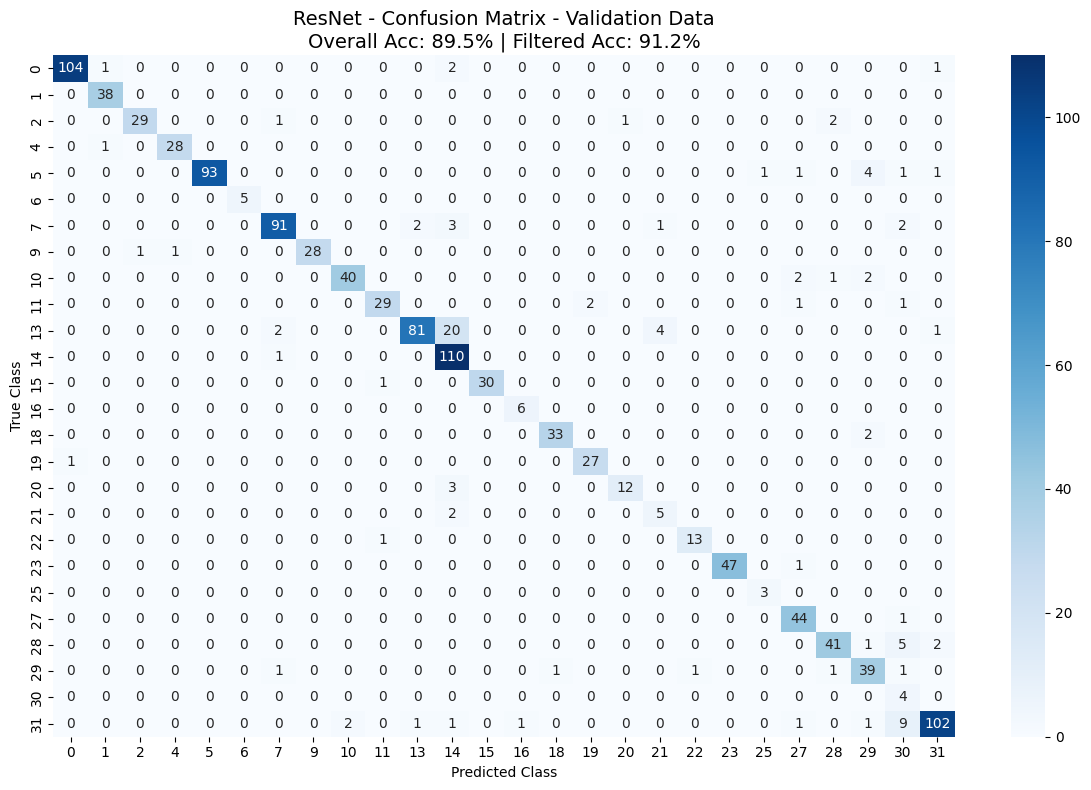


ResNet Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       109
           1       0.95      1.00      0.97        38
           2       0.97      0.81      0.88        36
           4       0.97      0.97      0.97        29
           5       1.00      0.89      0.94       105
           6       1.00      1.00      1.00         5
           7       0.95      0.91      0.93       100
           9       1.00      0.90      0.95        31
          10       0.95      0.89      0.92        45
          11       0.94      0.88      0.91        33
          13       0.96      0.74      0.84       110
          14       0.78      0.97      0.87       113
          15       1.00      0.97      0.98        31
          16       0.86      1.00      0.92         6
          18       0.97      0.89      0.93        37
          19       0.93      0.87      0.90        31
          20       0.92      0.80      0.86       

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm_resnet = confusion_matrix(y_resnet, y_hat_resnet, labels=valid_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=valid_classes,
            yticklabels=valid_classes)
plt.title(f'ResNet - Confusion Matrix - Validation Data\n'
          f'Overall Acc: {overall_acc_resnet*100:.1f}% | '
          f'Filtered Acc: {filtered_acc_resnet*100:.1f}%',
          fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

print("\nResNet Classification Report:")
print(classification_report(y_resnet, y_hat_resnet,
                           labels=valid_classes,
                           target_names=[str(cls) for cls in valid_classes],
                           zero_division=0))

### 8.6. Export Model
The model will be saved in the 'models' folder located in the same directory as this .ipynb file.

In [ ]:
# Define your desired directory
save_dir = './models'
model2_name = 'ResNet50_model.keras'

# Create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save to that directory
model2_path = os.path.join(save_dir, model2_name)
model2.save(model2_path)
print(f"Model saved to: {model2_path}")

Model saved to: ./models/ResNet50_model.keras


## 9. Model: Vision  Transformer (ViT)

To test and evaluate non-CNN performance, we used
- a ViT built from scratch, guided by the official Keras documentation on image classification with ViTs

https://keras.io/examples/vision/image_classification_with_vision_transformer/and
- and a pre-trained vit_b_16 from HuggingFace, implemented with reference to a GitHub repository demonstration on transfer learning with a ViT model pre-trained on ImageNet and applied to a custom dataset.

https://github.com/GutlapalliNikhil/ImageClassification_VIT_TransferLearning/tree/main

### 9.1 Core ViT Components

In [ ]:
## Input Specifications
input_shape = (224,224,3)    # 224x224 RGB images
num_classes = 32             # 32 classification categories
batch_size = 64              # Training batch size
image_size = 224             # Input image size

## Patch Creation
patch_size = 32              # Divide image into 32x32 patches
num_patches = 49             # (224/32) * (224/32) = 7*7 = 49 patches

## Patch Embedding
projection_dim = 216         # Dimension for patch embeddings

## Transformer Architecture
num_heads = 12               # Multi-head attention heads
transformer_layers = 6       # Number of transformer blocks
transformer_units = [512, 216]  # MLP sizes in each transformer block

## MLP Head for Classification
mlp_head_units = [512, 128]  # Final classification head

## Training Configuration
learning_rate = 0.001        # Optimiser step size
weight_decay = 0.0001        # L2 regularisation to prevent overfitting
num_epochs = 10              # Training iterations

### 9.2 MLP Function
The mlp function implements a Multi-Layer Perceptron - a fundamental feedforward neural network architecture that serves as a building block within the ViT model.

In [ ]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


### 9.3 Patching
The Patches class is a custom Keras layer that converts input images into sequences of flattened patches, serving as the fundamental preprocessing step for ViT. This operation transforms 2D images into 1D sequences of "visual tokens" analogous to word tokens in Natural Language Processing transformers, helping the model to capture small specific patterns across the electrical components.

In [ ]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]

        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = tf.image.extract_patches(
            images,
            sizes=[1, self.patch_size, self.patch_size, 1],  # Patch size (height, width, channels)
            strides=[1, self.patch_size, self.patch_size, 1],  # Stride (step between patches)
            rates=[1, 1, 1, 1],  # Always rate 1 for no dilations
            padding="VALID"  # No padding, so patches fit perfectly
        )

        # Reshape patches: (batch_size, num_patches_h * num_patches_w, patch_size * patch_size * channels)
        patches = tf.reshape(
            patches,
            [batch_size, num_patches_h * num_patches_w, self.patch_size * self.patch_size * channels]
        )

        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


An example of the patches for one image

Image size: 224 X 224
Patch size: 32 X 32
Patches per image: 49
Elements per patch: 3072


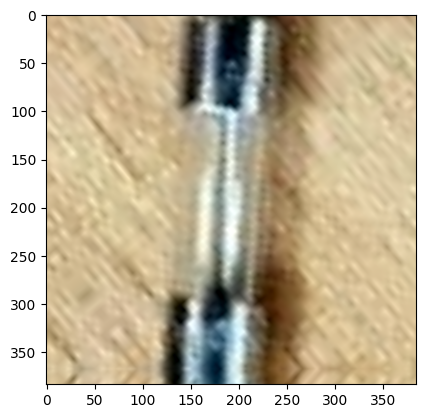

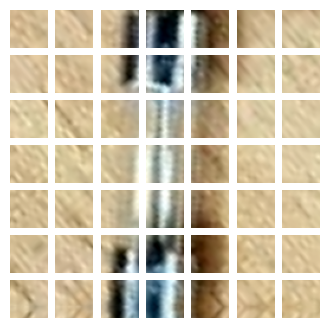

In [ ]:
for augmented_image, one_hot_label in train_dataset.take(1):
    image = augmented_image[0].numpy()

    resized_image = ops.image.resize(
        ops.convert_to_tensor([image]), size = (image_size,image_size)
    )
    #resize image

    plt.imshow(image.astype("uint8"))

    patches = Patches(patch_size)(resized_image)

    print(f"Image size: {image_size} X {image_size}")
    print(f"Patch size: {patch_size} X {patch_size}")
    print(f"Patches per image: {patches.shape[1]}")
    print(f"Elements per patch: {patches.shape[-1]}")


    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize = (4,4))
    for i,patch in enumerate(patches[0]):
        ax = plt.subplot(n, n, i + 1)
        patch_img= ops.reshape(patch, (patch_size, patch_size, 3))
        plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
        plt.axis("off")





Patch Encoding Layer

In [ ]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        batch_size = tf.shape(patches)[0]
        positions = tf.expand_dims(tf.range(self.num_patches), axis=0)  # Shape: (1, num_patches)
        projected_patches = self.projection(patches)  # Shape: (batch_size, num_patches, projection_dim)
        position_embeddings = self.position_embedding(positions)  # Shape: (1, num_patches, projection_dim)
        encoded_patches = projected_patches + position_embeddings  # Shape: (batch_size, num_patches, projection_dim)
        return encoded_patches

## 9.4. Finding Optimal Epoch Number using Stratified 3-Fold Training with ViT

1. Load & Prepare Data:

    - Loads training images resized to 224×224

    - Uses stratified splitting into 3 folds

2. Create 3 Training Cycles:

    - Each fold: 2/3 data for training, 1/3 for validation

    - Repeats 3 times with different splits

3. Build Custom ViT Model Each Time:

    - Image Patching: Splits images into smaller patches

    - Patch Encoding: Converts patches into embeddings

    - Transformer Layers: Uses multi-head attention and MLP blocks

    - Classification Head: Final layers for 32-class prediction

Key Differences from Previous CNN Models:

- Architecture: Pure Transformer (no convolutions)

- Training Model: ViT built from scratch (not pre-trained)

- Approach: Self-attention mechanism instead of convolutional features

In [ ]:
train_df = tf.keras.utils.image_dataset_from_directory(
    folder + '/dataset_cropped/train',
    image_size=(224,224),
    batch_size=None,
    label_mode='int',
    shuffle=False,
    seed=1244
)

file_paths = np.array(train_df.file_paths)
labels = np.array([label.numpy() for _, label in train_df])

skfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=1244)

ViT_history = {}

def create_fold_dataset(paths, labels, batch_size=64, shuffle=False):
    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [224, 224])  # ResNet input size
        img = tf.cast(img, tf.float32)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=1244)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size)

Found 4896 files belonging to 32 classes.


In [ ]:
for fold_no, (train_idx, val_idx) in enumerate(skfold.split(file_paths, labels), 1):
    print(f"\n===== Training ViT Fold {fold_no} =====\n")


    train_paths, val_paths = file_paths[train_idx], file_paths[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]

    train_fold_dataset = create_fold_dataset(train_paths, train_labels, shuffle=True)
    val_fold_dataset   = create_fold_dataset(val_paths, val_labels, shuffle=False)


    train_fold_dataset = train_fold_dataset.map(cv_preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    val_fold_dataset   = val_fold_dataset.map(cv_preprocess_test,  num_parallel_calls=tf.data.AUTOTUNE)


    unique_classes, counts = np.unique(train_labels, return_counts=True)
    class_weight_values = compute_class_weight("balanced", classes=unique_classes, y=train_labels)
    class_weight_dict = {cls: w for cls, w in zip(unique_classes, class_weight_values)}



    inputs = keras.Input(shape=(224,224,3))
    patches = Patches(patch_size)(inputs)


    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(num_classes)(features)
    # Create the Keras model.
    ViT = keras.Model(inputs=inputs, outputs=logits)

    ViT.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = ViT.fit(
        train_fold_dataset,
        validation_data=val_fold_dataset,
        class_weight=class_weight_dict,
        epochs=10,
        verbose=1
    )

    ViT_history[fold_no] = history


===== Training ViT Fold 1 =====


Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.0306 - loss: 8.2079 - val_accuracy: 0.0325 - val_loss: 8.8788
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.0358 - loss: 8.3117 - val_accuracy: 0.0270 - val_loss: 8.4846
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.0248 - loss: 8.1819 - val_accuracy: 0.0270 - val_loss: 8.4640
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.0343 - loss: 8.0041 - val_accuracy: 0.0453 - val_loss: 8.5442
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.0306 - loss: 8.1269 - val_accuracy: 0.0270 - val_loss: 8.0999
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.0334 - loss: 8.2022 - val_accuracy: 0.0325 - val_loss: 7.8642
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.0362 - loss: 8.0540 - val_accuracy: 0.0680 - val_loss: 8.8646
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.0414 - loss: 7.7530

### 9.5. Graphs of Training vs. Validation Loss/Accuracy over 10 Epochs for Each Fold

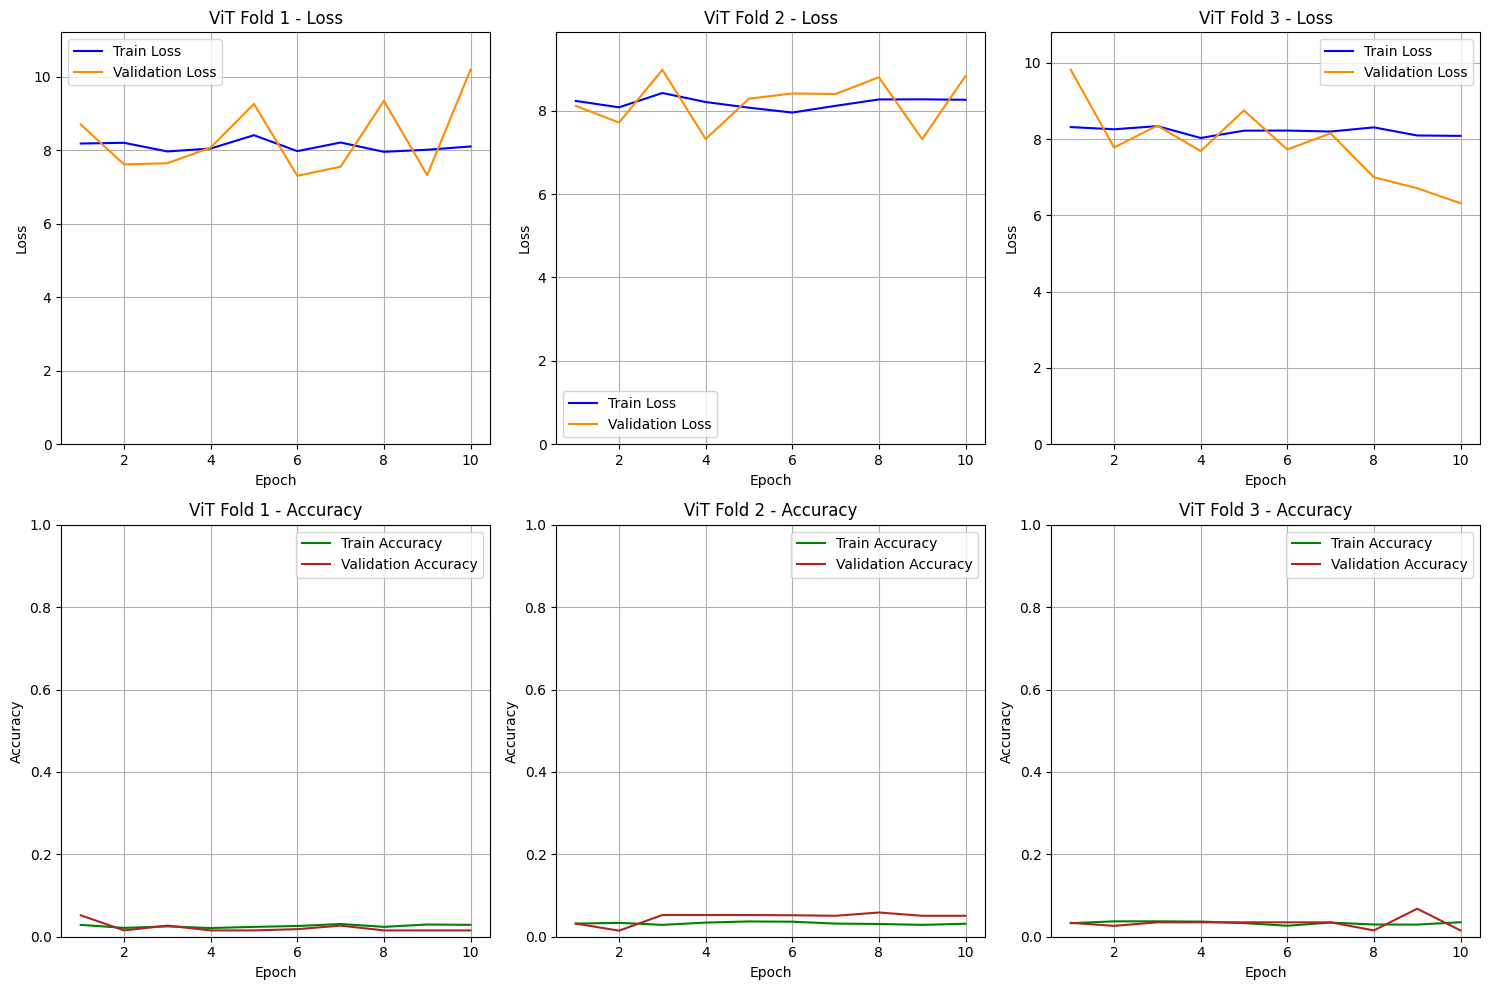

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
epochs = range(1, 11)

for i in range(1, 4):
    history = ViT_history[i]
    train_loss = history.history['loss']
    train_acc = history.history['accuracy']
    val_loss = history.history['val_loss']
    val_acc = history.history['val_accuracy']

    # Top row: Loss plots
    axes[0, i-1].plot(epochs, train_loss, color='blue', label='Train Loss')
    axes[0, i-1].plot(epochs, val_loss, color='darkorange', label='Validation Loss')
    axes[0, i-1].set_ylim(0, max(max(train_loss), max(val_loss)) * 1.1)  # Dynamic ylim
    axes[0, i-1].set_title(f"ViT Fold {i} - Loss")
    axes[0, i-1].set_xlabel('Epoch')
    axes[0, i-1].set_ylabel('Loss')
    axes[0, i-1].legend()
    axes[0, i-1].grid(True)

    # Bottom row: Accuracy plots
    axes[1, i-1].plot(epochs, train_acc, color='green', label='Train Accuracy')
    axes[1, i-1].plot(epochs, val_acc, color='firebrick', label='Validation Accuracy')
    axes[1, i-1].set_ylim(0, 1.0)  # Accuracy from 0 to 1
    axes[1, i-1].set_title(f"ViT Fold {i} - Accuracy")
    axes[1, i-1].set_xlabel('Epoch')
    axes[1, i-1].set_ylabel('Accuracy')
    axes[1, i-1].legend()
    axes[1, i-1].grid(True)

plt.tight_layout()
plt.show()

Choosing epoch = 5

Based on the training logs showing consistently poor performance across all folds with accuracy stagnating around 3% (essentially random guessing for 32 classes) and no meaningful improvement beyond epoch 5, using 5 epochs provides the same diagnostic value as 10 epochs while being 44% faster computationally. Since the model fails to learn meaningful patterns regardless of training duration, limiting to 5 epochs allows for quicker iteration cycles to address fundamental issues like data preprocessing, learning rate tuning, or architectural suitability without wasting computational resources on additional unproductive epochs.

### 9.6. Training

Uses a pre-trained vit_b_16.

Performs computation on CPU instead of GPU.

In [ ]:
device = torch.device("cpu")

This code sets up a comprehensive data loading and preprocessing pipeline using PyTorch's torchvision utilities for image classification tasks. The pipeline handles training, validation, and testing datasets with appropriate transforms and data loading configurations.

In [ ]:
train_dir = folder + "/dataset_cropped/train"
test_dir = folder + "/dataset_cropped/test"
val_dir = folder + "/dataset_cropped/valid"

BATCH_SIZE = 4


train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
test_data = datasets.ImageFolder(test_dir, transform=val_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_transforms)

val_dataloader = DataLoader(
      val_data,
      batch_size=BATCH_SIZE,
      shuffle=False,
      pin_memory=False,
      num_workers=4,

)


class_names = train_data.classes

train_dataloader = DataLoader(
      train_data,
      batch_size=BATCH_SIZE,
      shuffle=True,
      pin_memory=False,
      num_workers=4,
)

test_dataloader = DataLoader(
      test_data,
      batch_size=BATCH_SIZE,
      shuffle=False,
      pin_memory=False,
)


This code sets up a pre-trained Vision Transformer (ViT-B/16) model and customises it for a specific classification task using transfer learning.

In [ ]:
vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
vit_model = torchvision.models.vit_b_16(weights = vit_weights)

for parameter in vit_model.parameters():
    parameter.requires_grad = False

vit_model.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)
vit_model.heads.dropout = nn.Dropout(p=0.3)

1. Setup Phase:

    - Configure optimizer (Adam) and loss function

    - Initialise tracking for metrics

2. Training Loop (5 epochs):

    - Forward Pass: Get predictions from ViT model

    - Calculate Loss: Compare predictions with true labels

    - Backward Pass: Update model weights via backpropagation

    - Track Accuracy: Measure how many predictions are correct

3. Validation Phase:

    - Switch model to evaluation mode

    - Test on validation data without weight updates

    - Calculate validation loss and accuracy

4. Progress Tracking:

    - Print metrics after each epoch

    - Store all results for later analysis

    - Monitor both training and validation performance

Key Characteristics:
  - Framework: PyTorch (different from previous TensorFlow/Keras code used for training CNN models)

  - Model is pre-trained and not built from scratch

In [ ]:
optimizer = torch.optim.Adam(params=vit_model.parameters(), lr=1e-4, weight_decay=1e-4)

loss_fn = torch.nn.CrossEntropyLoss()

vit_model.to(device)

epochs = 5

results = {"train_loss": [],
               "train_acc": [],
               "val_loss": [],
               "val_acc": []
}

for epoch in tqdm(range(epochs)):

	vit_model.train()

	train_loss, train_acc = 0, 0

	for batch, (X, y) in enumerate(train_dataloader):

		X, y = X.to(device), y.to(device)

		y_pred = vit_model(X)

		loss = loss_fn(y_pred, y)

		train_loss += loss.item()

		optimizer.zero_grad()

		loss.backward()

		optimizer.step()

		y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
		train_acc += (y_pred_class == y).sum().item()/len(y_pred)

	train_loss = train_loss / len(train_dataloader)

	train_acc = train_acc / len(train_dataloader)

	vit_model.eval()

	val_loss, val_acc = 0, 0

	with torch.inference_mode():

		for batch, (X, y) in enumerate(val_dataloader):

			X, y = X.to(device), y.to(device)

			val_pred_logits = vit_model(X)

			loss = loss_fn(val_pred_logits, y)

			val_loss += loss.item()

			val_pred_labels = val_pred_logits.argmax(dim=1)

			val_acc += ((val_pred_labels == y).sum().item()/len(val_pred_labels))

	val_loss = val_loss / len(val_dataloader)

	val_acc = val_acc / len(val_dataloader)

	print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"valloss: {val_loss:.4f} | "
          f"val_acc: {val_acc:.4f}"
	)

	results["train_loss"].append(train_loss)
	results["train_acc"].append(train_acc)
	results["val_loss"].append(val_loss)
	results["val_acc"].append(val_acc)

 20%|██        | 1/5 [16:34<1:06:18, 994.72s/it]

Epoch: 1 | train_loss: 2.2268 | train_acc: 0.5621 | valloss: 3.2565 | val_acc: 0.1477


 40%|████      | 2/5 [56:42<1:31:18, 1826.06s/it]

Epoch: 2 | train_loss: 1.0571 | train_acc: 0.8464 | valloss: 3.6983 | val_acc: 0.1955


 60%|██████    | 3/5 [1:16:37<51:15, 1537.65s/it]

Epoch: 3 | train_loss: 0.6831 | train_acc: 0.8950 | valloss: 4.2861 | val_acc: 0.1906


 80%|████████  | 4/5 [1:33:19<22:06, 1326.28s/it]

Epoch: 4 | train_loss: 0.5079 | train_acc: 0.9259 | valloss: 4.8218 | val_acc: 0.1881


100%|██████████| 5/5 [3:53:01<00:00, 2796.38s/it]

Epoch: 5 | train_loss: 0.3979 | train_acc: 0.9377 | valloss: 5.3155 | val_acc: 0.1922


This code shows the model performance after completing the training and validation phases, indicating how well the Vision Transformer will perform in real-time.

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()

test_results = {"test_loss": 0, "test_acc": 0}

vit_model.eval()

test_loss, test_acc = 0, 0

with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
        X, y = X.to(device), y.to(device)

        test_pred_logits = vit_model(X)

        loss = loss_fn(test_pred_logits, y)
        test_loss += loss.item()

        test_pred_labels = test_pred_logits.argmax(dim=1)
        test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

test_loss = test_loss / len(test_dataloader)
test_acc = test_acc / len(test_dataloader)

test_results["test_loss"] = test_loss
test_results["test_acc"] = test_acc

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Test Loss: 4.4962 | Test Accuracy: 0.2262


### 9.7. Export Model
The model will be saved in the 'models' folder located in the same directory as this .ipynb file.

In [ ]:
ViT.save("./model/ViT1.keras")
torch.save(vit_model.state_dict(), "./models/vit2.pth")

### 9.8. Conclusion


A key reason for the ViT's significant poor performance is its inherent data hunger compared to Convolutional Neural Networks (CNN) like EfficientNetV2S & ResNet50. ViTs lack the inductive biases (translation equivariance, locality) that CNN possess, forcing ViTs to learn these visual principles entirely from scratch. This requires substantially larger datasets (i.e. often millions of images) to achieve competitive performance, whereas CNNs can deliver strong results with only thousands of training examples. Given our limited dataset size, the ViT architecture fundamentally struggles to learn meaningful representations, making it unsuitable for this project scope. Thus, it will be **excluded** in favor of more data-efficient CNN architectures.

## 10. Comparison between EfficientNetV2S & ResNet50

1. Confusion-Matrix Heatmap
    - Rows: True Classes
    - Columns: Predicted Classes
    - Dark Diagonals:  Correct Predictions
    - Off-Diagonals: Missed Predictions

2. Summary Table with Performance Metrics

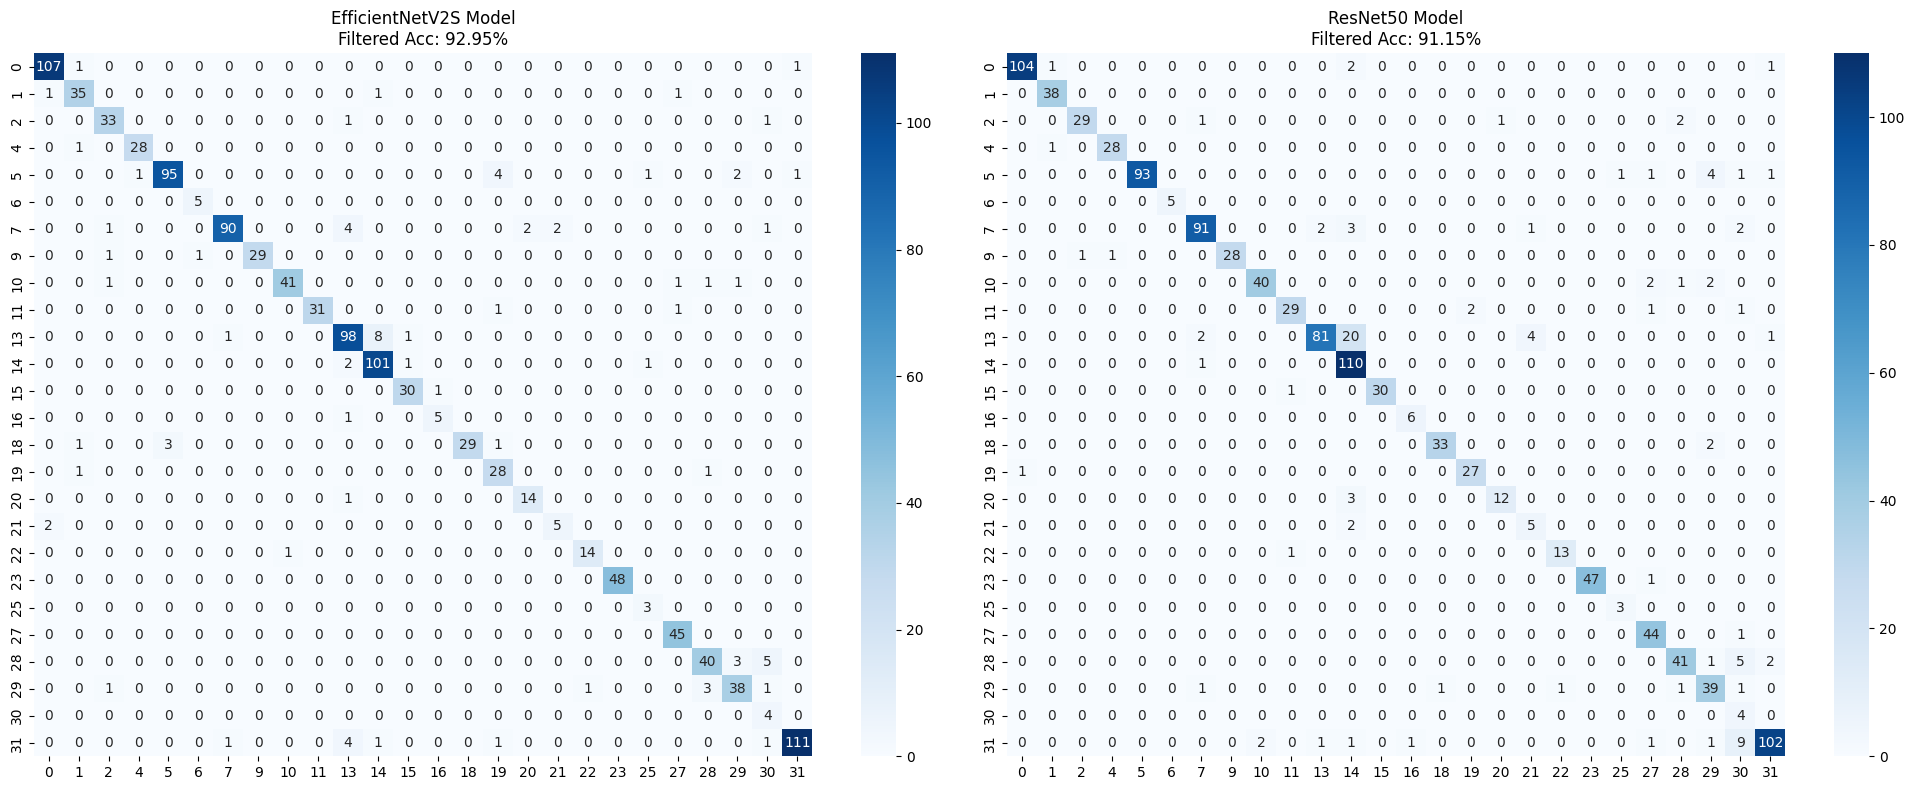

Comprehensive Model Comparison Table
Metric                    EfficientNetV2S ResNet50        Delta     
Overall Accuracy          91.56%         89.50%         +2.07%
Filtered Accuracy         92.95%         91.15%         +1.79%
Macro F1-Score            0.746             0.763             -0.017
Weighted F1-Score         0.924             0.909             +0.016
Macro Precision           0.740             0.767             -0.027
Macro Recall              0.769             0.784             -0.016
Missing Predictions       18             22             -4


In [ ]:
# Comparison between both models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# EfficientNetV2S model confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=valid_classes,
            yticklabels=valid_classes, ax=ax1)
ax1.set_title(f'EfficientNetV2S Model\nFiltered Acc: {filtered_acc*100:.2f}%')

# ResNet confusion matrix
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=valid_classes,
            yticklabels=valid_classes, ax=ax2)
ax2.set_title(f'ResNet50 Model\nFiltered Acc: {filtered_acc_resnet*100:.2f}%')

plt.tight_layout()
plt.show()


# Calculate comprehensive metrics for both models
metrics_effnet = {
    'accuracy': overall_acc,
    'filtered_accuracy': filtered_acc,
    'macro_precision': precision_score(y, y_hat, average='macro', zero_division=0),
    'macro_recall': recall_score(y, y_hat, average='macro', zero_division=0),
    'macro_f1': f1_score(y, y_hat, average='macro', zero_division=0),
    'weighted_precision': precision_score(y, y_hat, average='weighted', zero_division=0),
    'weighted_recall': recall_score(y, y_hat, average='weighted', zero_division=0),
    'weighted_f1': f1_score(y, y_hat, average='weighted', zero_division=0),
    'missing_predictions': np.sum(missing_mask)
}

metrics_resnet = {
    'accuracy': overall_acc_resnet,
    'filtered_accuracy': filtered_acc_resnet,
    'macro_precision': precision_score(y_resnet, y_hat_resnet, average='macro', zero_division=0),
    'macro_recall': recall_score(y_resnet, y_hat_resnet, average='macro', zero_division=0),
    'macro_f1': f1_score(y_resnet, y_hat_resnet, average='macro', zero_division=0),
    'weighted_precision': precision_score(y_resnet, y_hat_resnet, average='weighted', zero_division=0),
    'weighted_recall': recall_score(y_resnet, y_hat_resnet, average='weighted', zero_division=0),
    'weighted_f1': f1_score(y_resnet, y_hat_resnet, average='weighted', zero_division=0),
    'missing_predictions': np.sum(missing_mask_resnet)
}

# Enhanced comparison table
print("="*65)
print("Comprehensive Model Comparison Table")
print("="*65)
print(f"{'Metric':<25} {'EfficientNetV2S':<15} {'ResNet50':<15} {'Delta':<10}")
print(f"{'Overall Accuracy':<25} {metrics_effnet['accuracy']*100:.2f}%{'':<8} {metrics_resnet['accuracy']*100:.2f}%{'':<8} {((metrics_effnet['accuracy'] - metrics_resnet['accuracy'])*100):+.2f}%")
print(f"{'Filtered Accuracy':<25} {metrics_effnet['filtered_accuracy']*100:.2f}%{'':<8} {metrics_resnet['filtered_accuracy']*100:.2f}%{'':<8} {((metrics_effnet['filtered_accuracy'] - metrics_resnet['filtered_accuracy'])*100):+.2f}%")
print(f"{'Macro F1-Score':<25} {metrics_effnet['macro_f1']:.3f}{'':<12} {metrics_resnet['macro_f1']:.3f}{'':<12} {metrics_effnet['macro_f1'] - metrics_resnet['macro_f1']:+.3f}")
print(f"{'Weighted F1-Score':<25} {metrics_effnet['weighted_f1']:.3f}{'':<12} {metrics_resnet['weighted_f1']:.3f}{'':<12} {metrics_effnet['weighted_f1'] - metrics_resnet['weighted_f1']:+.3f}")
print(f"{'Macro Precision':<25} {metrics_effnet['macro_precision']:.3f}{'':<12} {metrics_resnet['macro_precision']:.3f}{'':<12} {metrics_effnet['macro_precision'] - metrics_resnet['macro_precision']:+.3f}")
print(f"{'Macro Recall':<25} {metrics_effnet['macro_recall']:.3f}{'':<12} {metrics_resnet['macro_recall']:.3f}{'':<12} {metrics_effnet['macro_recall'] - metrics_resnet['macro_recall']:+.3f}")
print(f"{'Missing Predictions':<25} {metrics_effnet['missing_predictions']:<14} {metrics_resnet['missing_predictions']:<14} {metrics_effnet['missing_predictions'] - metrics_resnet['missing_predictions']:+.0f}")

## 10.2. Conclusion
### Given our imbalanced dataset with 32 equally important class, our final model will be **ResNet50**.

While EfficientNetV2S model achieves a higher filtered accuracy (92.95% vs 91.15%) and weighted F1-score (0.924 vs 0.909) than ResNet50, it is important to know that these metrics are heavily influenced by performance on the majority classes. Therefore, since all 32 classes have equal importance, macro-averaged metrics provide a more appropriate evaluation criterion for 2 models.

ResNet50 has a higher macro F1-Score (0.763 vs 0.746), macro precision (0.767 vs 0.740) and a higher macro recall (0.784 vs 0.769) than EfficientNetV2S. These metrics shows that ResNet50 can provide a more balanced and consistent predictions across all classes, including minority classes that are underrepresented in the training data.

Therefore, ResNet50 is chosen as our final model due to its better capability in correctly identitfying objects from minority classes than EfficientNetV2S.

## 10.3. Final Model ResNet50 Implementaion

In [11]:
final_resnet_train = create_proper_dataset(train_dataset)
final_resnet_test = create_proper_dataset(test_dataset)

finalModel = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
finalModel.trainable = False
inputs = keras.Input(shape = (224, 224, 3))

x = finalModel(inputs, training = False)

x = keras.layers.GlobalAveragePooling2D()(x)

outputs = keras.layers.Dense(32, activation='softmax')(x)

finalModel = keras.Model(inputs, outputs)

finalModel.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
finalHistory = finalModel.fit(final_resnet_train, validation_data=final_resnet_test,
                      epochs = 6,
                      class_weight=class_weights
)

Epoch 1/6
76/76 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.6223 - loss: 1.5373 - val_accuracy: 0.8012 - val_loss: 0.7270
Epoch 2/6


2025-10-31 22:58:25.905615: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/BonnieToo/Personal/university/IT1244/ECI/venv-eci/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


76/76 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.8914 - loss: 0.4706 - val_accuracy: 0.8744 - val_loss: 0.5044
Epoch 3/6


2025-10-31 23:01:22.846595: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


76/76 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.9202 - loss: 0.3345 - val_accuracy: 0.8759 - val_loss: 0.4641
Epoch 4/6
76/76 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9334 - loss: 0.2628 - val_accuracy: 0.9088 - val_loss: 0.3657
Epoch 5/6


2025-10-31 23:07:21.288473: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


76/76 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9505 - loss: 0.2123 - val_accuracy: 0.8939 - val_loss: 0.4031
Epoch 6/6
76/76 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9583 - loss: 0.1829 - val_accuracy: 0.9193 - val_loss: 0.3167


2025-10-31 23:14:31.976637: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


ResNet Model Performance:
Overall Accuracy: 90.98%
Filtered Accuracy (valid classes only): 91.74%
Number of predictions in missing classes: 10


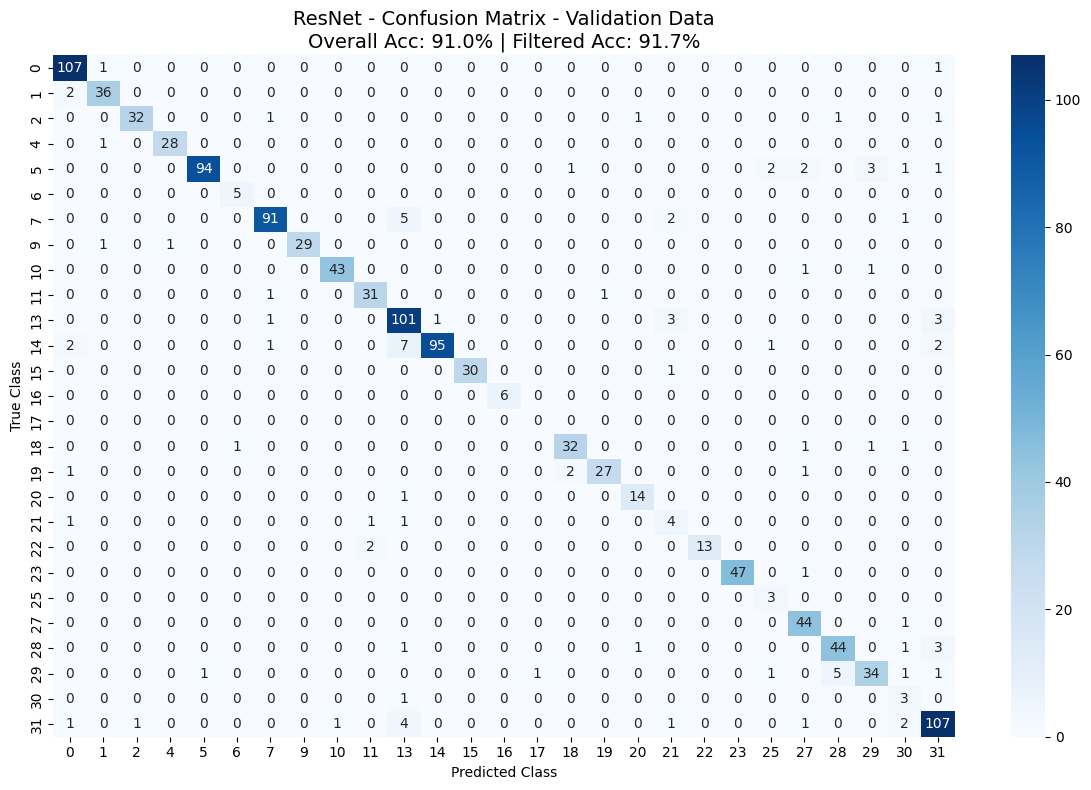


ResNet Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       109
           1       0.92      0.95      0.94        38
           2       0.97      0.89      0.93        36
           4       0.97      0.97      0.97        29
           5       0.99      0.90      0.94       105
           6       0.83      1.00      0.91         5
           7       0.96      0.91      0.93       100
           9       1.00      0.94      0.97        31
          10       0.98      0.96      0.97        45
          11       0.91      0.94      0.93        33
          13       0.83      0.92      0.87       110
          14       0.99      0.84      0.91       113
          15       1.00      0.97      0.98        31
          16       1.00      1.00      1.00         6
          17       0.00      0.00      0.00         0
          18       0.91      0.86      0.89        37
          19       0.96      0.87      0.92       

In [16]:
# Generate predictions for ResNet50 model
y_final, y_hat_final = [], []

for images, labels in resnet_val:
    predictions = finalModel.predict(images, verbose=0)
    y_hat_final.append(np.argmax(predictions, axis=1))
    y_final.append(np.argmax(labels.numpy(), axis=1))

y_final, y_hat_final = np.concatenate(y_final), np.concatenate(y_hat_final)

test_class_distribution = {0: 8, 1: 90, 2: 17, 4: 19, 5: 12, 6: 1, 7: 27, 9: 20, 10: 23, 11: 18,
                            13: 24, 14: 22, 15: 89, 16: 2, 17: 2, 18: 82, 19: 88, 20: 5, 21: 8,
                            22: 4, 23: 24, 25: 1, 27: 22, 28: 22, 29: 22, 30: 2, 31: 15}

valid_classes = list(test_class_distribution.keys())
missing_classes = [i for i in range(32) if i not in valid_classes]

overall_acc_final = np.mean(y_hat_final == y_final)
missing_mask_final = np.isin(y_hat_final, missing_classes)
valid_mask_final = np.isin(y_hat_final, valid_classes)
filtered_acc_final = np.mean(y_hat_final[valid_mask_final] == y_final[valid_mask_final])

print(f"ResNet Model Performance:")
print(f"Overall Accuracy: {overall_acc_final*100:.2f}%")
print(f"Filtered Accuracy (valid classes only): {filtered_acc_final*100:.2f}%")
print(f"Number of predictions in missing classes: {np.sum(missing_mask_final)}")
from sklearn.metrics import confusion_matrix, classification_report

cm_resnet = confusion_matrix(y_final, y_hat_final, labels=valid_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=valid_classes,
            yticklabels=valid_classes)
plt.title(f'ResNet - Confusion Matrix - Validation Data\n'
          f'Overall Acc: {overall_acc_final*100:.1f}% | '
          f'Filtered Acc: {filtered_acc_final*100:.1f}%',
          fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

print("\nResNet Classification Report:")
print(classification_report(y_final, y_hat_final,
                           labels=valid_classes,
                           target_names=[str(cls) for cls in valid_classes],
                           zero_division=0))

In [17]:
metrics_final = {
    'accuracy': overall_acc_final,
    'filtered_accuracy': filtered_acc_final,
    'macro_precision': precision_score(y_final, y_hat_final, average='macro', zero_division=0),
    'macro_recall': recall_score(y_final, y_hat_final, average='macro', zero_division=0),
    'macro_f1': f1_score(y_final, y_hat_final, average='macro', zero_division=0),
    'weighted_precision': precision_score(y_final, y_hat_final, average='weighted', zero_division=0),
    'weighted_recall': recall_score(y_final, y_hat_final, average='weighted', zero_division=0),
    'weighted_f1': f1_score(y_final, y_hat_final, average='weighted', zero_division=0),
    'missing_predictions': np.sum(missing_mask_final)
}

# Enhanced comparison table
print("="*40)
print("Final Model Evaluation Table")
print("="*40)
print(f"{'Metric':<25} {'ResNet50':<15}")
print(f"{'Overall Accuracy':<25}{metrics_final['accuracy']*100:.2f}")
print(f"{'Filtered Accuracy':<25}{metrics_final['filtered_accuracy']*100:.2f}")
print(f"{'Macro F1-Score':<25}{metrics_final['macro_f1']:.3f}")
print(f"{'Weighted F1-Score':<25}{metrics_final['weighted_f1']:.3f}")
print(f"{'Macro Precision':<25}{metrics_final['macro_precision']:.3f}")
print(f"{'Macro Recall':<25}{metrics_final['macro_recall']:.3f}")
print(f"{'Missing Predictions':<25}{metrics_final['missing_predictions']:<14}")

Final Model Evaluation Table
Metric                    ResNet50       
Overall Accuracy         90.98
Filtered Accuracy        91.74
Macro F1-Score           0.735
Weighted F1-Score        0.917
Macro Precision          0.730
Macro Recall             0.758
Missing Predictions      10            


In [18]:
# Define your desired directory
save_dir = './models'
finalModel_name = 'final_model.keras'

# Create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save to that directory
finalModel_path = os.path.join(save_dir, finalModel_name)
finalModel.save(finalModel_path)
print(f"Model saved to: {finalModel_path}")

Model saved to: ./models/final_model.keras
